In [38]:
import numpy as np
import torch
import os
import trimesh

MOTION_PATH = 'data/neuraldome/sequences_canonical'
OBJECT_PATH = 'data/neuraldome/objects'
OBJECT_BPS_PATH = 'data/neuraldome/objects_bps'
name = 'subject01_baseball_0'
obj_name = 'baseball'

    

In [30]:
# Load human raw data
with np.load(os.path.join(MOTION_PATH, name, 'human.npz'), allow_pickle=True) as f:
    poses = f['poses']                # smplh(or smplx) poses
    betas = f['betas']                # body shape
    trans = f['trans']                # global body position
    gender = str(f['gender'])         # gender

# Load object raw data
with np.load(os.path.join(MOTION_PATH, name, 'object.npz'), allow_pickle=True) as f:
    obj_angles = f['angles']          # rotation for rigid object, axis angle
    obj_trans = f['trans']            # translation for rigid object
    obj_name = str(f['name'])         # object name


print("=" * 50)
print("Variable Information".center(50))
print("=" * 50)
print(f"Poses shape: {poses.shape}")
print(f"Betas shape: {betas.shape}")
print(f"Trans shape: {trans.shape}")
print(f"Gender: {gender}")
print(f"Object angles shape: {obj_angles.shape}")
print(f"Object translation shape: {obj_trans.shape}")
print(f"Object name: {obj_name}")
print("=" * 50)


               Variable Information               
Poses shape: (190, 156)
Betas shape: (16,)
Trans shape: (190, 3)
Gender: neutral
Object angles shape: (190, 3)
Object translation shape: (190, 3)
Object name: baseball


In [12]:
# Load the text annotations
with open(os.path.join(MOTION_PATH, name, 'text.txt'), 'r') as f:
    texts = f.readlines()             # Read all the texts for this sequence
texts

['A person picks up a baseball with right hand, holds it with left hand, and touches their head with their right hand.#A/DET person/NOUN pick/VERB up/ADP a/DET baseball/NOUN with/ADP right/ADJ hand/NOUN hold/VERB it/PRON with/ADP left/ADJ hand/NOUN and/CCONJ touch/VERB their/PRON head/NOUN with/ADP their/PRON right/ADJ hand/NOUN#0.0#0.0\n',
 'An individual grasps a baseball with their right hand, secures it with their left, and then touches their head with the right hand.#An/DET individual/NOUN grasp/VERB a/DET baseball/NOUN with/ADP their/PRON right/ADJ hand/NOUN secure/VERB it/PRON with/ADP their/PRON left/ADJ and/CCONJ then/ADV touch/VERB their/PRON head/NOUN with/ADP the/DET right/ADJ hand/NOUN#0.0#0.0\n',
 'A person picks up a baseball with their right hand, holds it with their left, and touches their head with the right.#A/DET person/NOUN pick/VERB up/ADP a/DET baseball/NOUN with/ADP their/PRON right/ADJ hand/NOUN hold/VERB it/PRON with/ADP their/PRON left/ADJ and/CCONJ touch/VER

In [19]:
# Load the action annotations
with open(os.path.join(MOTION_PATH, name, 'action.txt'), 'r') as f:
    action = f.readlines()             # Read the action for this sequence
action

['A person move the chair.#A/DET person/NOUN move/VERB the/DET chair/NOUN#0.0#0.0']

In [33]:
# Load the human joints and markers
human_markers = np.load(os.path.join(MOTION_PATH, name, 'markers.npy'))
human_joints = np.load(os.path.join(MOTION_PATH, name, 'joints.npy'))
print("=" * 50)
print("Variable Information".center(50))
print("=" * 50)
print("Markers shape:",human_markers.shape)
print("Joints shape:",human_joints.shape)
print("=" * 50)

               Variable Information               
Markers shape: (190, 77, 3)
Joints shape: (190, 52, 3)


In [44]:
object_sample_verts = np.load(os.path.join(OBJECT_PATH, obj_name, 'sample_points.npy'))
MESH = trimesh.load(os.path.join(OBJECT_PATH, obj_name, f'{obj_name}.obj'))
object_verts = MESH.vertices
object_faces = MESH.faces
object_bps = np.load(os.path.join(OBJECT_BPS_PATH, obj_name, f'{obj_name}_1024.npy'))


print("=" * 50)
print("Variable Information".center(50))
print("=" * 50)
print('Object sampled verts:',object_sample_verts.shape )
print('Object verts:', object_verts.shape )
print('Object faces:', object_faces.shape )
print('Object BPS:', object_bps.shape )
print("=" * 50)

               Variable Information               
Object sampled verts: (340, 3)
Object verts: (12642, 3)
Object faces: (19954, 3)
Object BPS: (1, 1024, 3)


In [32]:
# Load the representation
motion = np.load(os.path.join(MOTION_PATH, name, 'motion.npy'))
print("=" * 50)
print("Variable Information".center(50))
print("=" * 50)
print("Representation shape:", motion.shape)
print("=" * 50)

               Variable Information               
Representation shape: (190, 962)




The `motion.npy` file contains motion sequence data in the shape of `(N, D)`, where:

- **`N`**: Represents the number of frames in the sequence.
- **`D`**: Denotes the feature dimension, which is **962** in total.   

This dimension is comprised of two parts:

- Human motion (476 features): 
  - Marker positions (231 features): 73 markers, each with 3 spatial coordinates.
  - Marker velocities (231 features): The velocity of each of the 73 markers.
  - Ground contact (14 features): Information related to the subject's contact with the ground.
- Object motion (486 features): 
  - Translation and 6D rotation (9 features): Representing the object's position and orientation.
  - Velocity (9 features): The translational and rotational velocity of the object.
  - Relative representation (468 features): 78 relative representations(77 + 1 ground marker) , each with 6 components.

In [31]:
# Reshape and extract variables from the 'motion' array

# Markers positions:
# Reshaped into (-1, 77, 3) meaning there are 77 markers with 3 coordinates each.
markers = motion[:, :231].reshape(-1, 77, 3)

# Markers velocities:
# Reshaped into (-1, 77, 3) corresponding to 77 markers each having a 3D velocity vector.
markers_velocity = motion[:, 231:462].reshape(-1, 77, 3)

# Marker foot contact:
# Contains 14 values indicating foot contact statuses for markers.
marker_foot_contact = motion[:, 462:462+14]

# Object rotation (6D):
# Represents object rotation using a 6D continuous representation.
object_rotation_6d = motion[:, 476:476+6]

# Object translation:
# Contains the object's 3D translation values.
object_trans = motion[:, 482:485]

# Object angular velocity (6D):
# Represents the object's angular velocity in a 6-dimensional format.
object_ang_vel_6d = motion[:, 485:491]

# Object velocity:
# Contains the object's 3D linear velocity.
object_vel = motion[:, 491:494]

# Vectors from the object to markers:
# Reshaped into (-1, 77, 3) yielding a 3D vector for each of the 77 markers.
object2marker = motion[:, 494:494+77*3].reshape(-1, 77, 3)

# Vector from the object to the ground:
# Reshaped into (-1, 1, 3) representing the 3D vector for ground contact.
object2ground = motion[:, 725:725+3].reshape(-1, 1, 3)

# Canonical Object vertices corresponding to each marker:
# Reshaped into (-1, 77, 3) where each marker corresponds to one vertex (with 3 coordinates).
marker_correspond_canonical_object_verts = motion[:, 728:728+77*3].reshape(-1, 77, 3)

# Canonical Object vertex corresponding to the ground contact,:
# Reshaped into (-1, 1, 3) for the ground-related object vertex.
ground_correspond_canonical_object_verts = motion[:, 959:959+3].reshape(-1, 1, 3)

print("=" * 50)
print("Variable Information".center(50))
print("=" * 50)
print("Markers shape:", markers.shape)
print("Markers velocity shape:", markers_velocity.shape)
print("Marker foot contact shape:", marker_foot_contact.shape)
print("Object rotation (6D) shape:", object_rotation_6d.shape)
print("Object translation shape:", object_trans.shape)
print("Object angular velocity (6D) shape:", object_ang_vel_6d.shape)
print("Object velocity shape:", object_vel.shape)
print("Object-to-marker vectors shape:", object2marker.shape)
print("Object-to-ground vector shape:", object2ground.shape)
print("Marker-corresponding canonical object vertices shape:", marker_correspond_canonical_object_verts.shape)
print("Ground-corresponding canonical object vertex shape:", ground_correspond_canonical_object_verts.shape)
print("=" * 50)

               Variable Information               
Markers shape: (190, 77, 3)
Markers velocity shape: (190, 77, 3)
Marker foot contact shape: (190, 14)
Object rotation (6D) shape: (190, 6)
Object translation shape: (190, 3)
Object angular velocity (6D) shape: (190, 6)
Object velocity shape: (190, 3)
Object-to-marker vectors shape: (190, 77, 3)
Object-to-ground vector shape: (190, 1, 3)
Marker-corresponding canonical object vertices shape: (190, 77, 3)
Ground-corresponding canonical object vertex shape: (190, 1, 3)


Additional Verification from myside (Natcha): 
Sanity check before running 

In [37]:
import os

print("=" * 50)
print("Directory Information".center(50))
print("=" * 50)
print("cwd:", os.getcwd())
print("ls cwd:", sorted(os.listdir('.')))
print("models exists?", os.path.exists('models'))
print("models is symlink?", os.path.islink('models'))
if os.path.islink('models'):
    print("symlink target:", os.readlink('models'))
print("realpath:", os.path.realpath('models'))
print("=" * 50)

              Directory Information               
cwd: /home/natcha/Downloads/projects/InterAct
ls cwd: ['.git', '.gitignore', 'InterAct_license.pdf', 'README.md', 'assets', 'data', 'data_demo.ipynb', 'hoi_correction', 'human2object', 'install_human_body_prior.sh', 'install_pointnet2_ops.sh', 'models', 'object2human', 'paramUtil.py', 'process', 'requirements.txt', 'results', 'simulation', 'smplx', 'text2interaction', 'tmp', 'visualization']
models exists? True
models is symlink? True
symlink target: /media/natcha/Natcha_T7/InterAct_workspace/models
realpath: /media/natcha/Natcha_T7/InterAct_workspace/models


In [38]:
import os, smplx, torch

m = smplx.create('models', model_type='smplx', gender='neutral',
                 use_pca=False, flat_hand_mean=True, num_betas=16)
out = m(betas=torch.zeros(1, 16))


print("=" * 50)
print("SMPLX Information".center(50))
print("=" * 50)
print("smplx/ contents:", os.listdir('models/smplx'))
print("T-pose joints[0].shape:", out.joints.shape)   # expect (1, ~127, 3)
print("pelvis world position:", out.joints[0, 0].detach().numpy())
print("=" * 50)

                SMPLX Information                 
smplx/ contents: ['SMPLX_NEUTRAL.npz', 'version.txt', 'SMPLX_MALE.pkl', 'SMPLX_FEMALE.npz', 'smplx_npz.zip', 'SMPLX_MALE.npz', 'SMPLX_FEMALE.pkl', 'SMPLX_NEUTRAL.pkl']
T-pose joints[0].shape: torch.Size([1, 127, 3])
pelvis world position: [ 0.00312326 -0.35140747  0.01203655]


In [39]:
from smplx import joint_names

official = joint_names.JOINT_NAMES[:22]
BODY_NAMES = ['pelvis','left_hip','right_hip','spine1','left_knee','right_knee',
              'spine2','left_ankle','right_ankle','spine3','left_foot','right_foot',
              'neck','left_collar','right_collar','head','left_shoulder',
              'right_shoulder','left_elbow','right_elbow','left_wrist','right_wrist']

for i, (mine, off) in enumerate(zip(BODY_NAMES, official)):
    print(i, mine, off, mine == off)

0 pelvis pelvis True
1 left_hip left_hip True
2 right_hip right_hip True
3 spine1 spine1 True
4 left_knee left_knee True
5 right_knee right_knee True
6 spine2 spine2 True
7 left_ankle left_ankle True
8 right_ankle right_ankle True
9 spine3 spine3 True
10 left_foot left_foot True
11 right_foot right_foot True
12 neck neck True
13 left_collar left_collar True
14 right_collar right_collar True
15 head head True
16 left_shoulder left_shoulder True
17 right_shoulder right_shoulder True
18 left_elbow left_elbow True
19 right_elbow right_elbow True
20 left_wrist left_wrist True
21 right_wrist right_wrist True


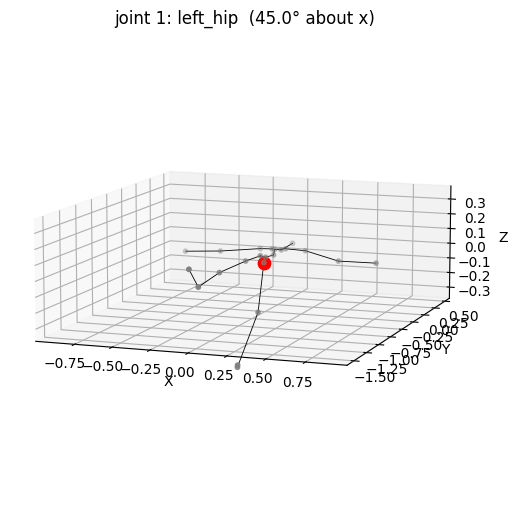

In [40]:
import os, numpy as np, torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

OUT_DIR = 'results/joint_dict'
os.makedirs(OUT_DIR, exist_ok=True)

BODY_NAMES = ['pelvis','left_hip','right_hip','spine1','left_knee','right_knee',
              'spine2','left_ankle','right_ankle','spine3','left_foot','right_foot',
              'neck','left_collar','right_collar','head','left_shoulder',
              'right_shoulder','left_elbow','right_elbow','left_wrist','right_wrist']
PARENTS = [-1,0,0,0,1,2,3,4,5,6,7,8,9,9,9,12,13,14,16,17,18,19]
AXES = {'x':[1,0,0], 'y':[0,1,0], 'z':[0,0,1]}

# Fixed plot bounds so every figure has the same scale (compute from T-pose)
T = m(betas=torch.zeros(1, 16)).joints[0, :22].detach().numpy()
lo, hi = T.min(0) - 0.3, T.max(0) + 0.3

def render_body_joint(i, angle_deg=45.0, axis='x'):
    go = torch.zeros(1, 3)          # joint 0 -> global_orient
    bp = torch.zeros(1, 63)         # joints 1..21 -> body_pose (off-by-one!)
    rot = torch.tensor(np.deg2rad(angle_deg) * np.array(AXES[axis], dtype=np.float32))
    if i == 0:
        go[0] = rot
    else:
        bp[0, (i-1)*3 : i*3] = rot

    out = m(global_orient=go, body_pose=bp, betas=torch.zeros(1, 16))
    J = out.joints[0, :22].detach().numpy()

    fig = plt.figure(figsize=(5, 6))
    ax = fig.add_subplot(111, projection='3d')
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,1],J[k,1]],[J[p,2],J[k,2]], 'k-', lw=0.6)
    ax.scatter(J[:,0], J[:,1], J[:,2], c='gray', s=10)
    ax.scatter([J[i,0]],[J[i,1]],[J[i,2]], c='red', s=80)   # red = the pivot joint
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((hi-lo))
    ax.view_init(elev=10, azim=-70)
    ax.set_title(f"joint {i}: {BODY_NAMES[i]}  ({angle_deg}° about {axis})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/joint_{i:02d}_{BODY_NAMES[i]}_{axis}.png", dpi=100)
    plt.show()

# for i in range(22):
#     render_body_joint(i, angle_deg=45.0, axis='x')

render_body_joint(1, axis='x')   # left_hip



In [41]:
import os, pickle, glob

HUMOTO_UPBONE = '/media/natcha/Natcha_T7/InterAct_workspace/humoto_upbone'
pkls = sorted(glob.glob(os.path.join(HUMOTO_UPBONE, '*', '*.pkl')))
print(f"found {len(pkls)} pickles")
for p in pkls[:3]:
    print(" ", p)

# load the first one
with open(pkls[0], 'rb') as f:
    data = pickle.load(f)
print("type:", type(data))
print("keys/len:", data.keys() if isinstance(data, dict) else len(data))


found 10 pickles
  /media/natcha/Natcha_T7/InterAct_workspace/humoto_upbone/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244.pkl
  /media/natcha/Natcha_T7/InterAct_workspace/humoto_upbone/carry_organizer_with_both_hands_at_chest_height-436/carry_organizer_with_both_hands_at_chest_height-436.pkl
  /media/natcha/Natcha_T7/InterAct_workspace/humoto_upbone/carry_side_table_with_both_hands_walk_around-536/carry_side_table_with_both_hands_walk_around-536.pkl
type: <class 'dict'>
keys/len: dict_keys(['armature', 'objects'])


In [42]:
import pickle, numpy as np

with open(pkls[0], 'rb') as f:
    data = pickle.load(f)

arm = data['armature']        # list, length = T frames
objs = data['objects']        # dict (likely empty for public)

print("--- top level ---")
print(f"num frames T = {len(arm)}")
print(f"object names = {list(objs.keys())}")

frame0 = arm[0]
print(f"\nnum bones = {len(frame0)} (expect 65)")
print("first 5 bones:", list(frame0.keys())[:5])

# Real entry shape: flat 7-element list [w, x, y, z, loc_x, loc_y, loc_z]
hips = np.array(frame0['mixamorig:Hips'])
print(f"\nhips entry shape: {hips.shape}")
print(f"  quat (w,x,y,z): {np.round(hips[:4], 4)}")
print(f"  loc  (x,y,z)  : {np.round(hips[4:], 4)}")
print(f"  quat norm: {np.linalg.norm(hips[:4]):.4f}  (should be ~1.0)")

# Spot-check representative bones
print("\n--- frame 0 sample bones ---")
for b in ['mixamorig:Hips','mixamorig:Spine','mixamorig:LeftArm',
          'mixamorig:LeftForeArm','mixamorig:RightHand',
          'mixamorig:LeftUpLeg','mixamorig:Head']:
    e = np.array(frame0[b])
    print(f"  {b:32s} quat={np.round(e[:4],3)}  loc={np.round(e[4:],3)}")

# Object: confirm shape
obj_name = list(objs.keys())[0]
obj_traj = np.array(objs[obj_name])
print(f"\nobject '{obj_name}' trajectory shape: {obj_traj.shape}  (expect (T, 7))")
print(f"frame 0: quat={np.round(obj_traj[0,:4],3)}  loc={np.round(obj_traj[0,4:],3)}")

# Hips translation over time → confirms which axis is "up"
hips_traj = np.array([arm[t]['mixamorig:Hips'][4:] for t in range(len(arm))])
print(f"\nhips translation range over {len(arm)} frames:")
print(f"  x: [{hips_traj[:,0].min():.3f}, {hips_traj[:,0].max():.3f}]")
print(f"  y: [{hips_traj[:,1].min():.3f}, {hips_traj[:,1].max():.3f}]")
print(f"  z: [{hips_traj[:,2].min():.3f}, {hips_traj[:,2].max():.3f}]")


--- top level ---
num frames T = 293
object names = ['mixing_bowl', 'spatula', 'table', 'tray']

num bones = 65 (expect 65)
first 5 bones: ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck']

hips entry shape: (7,)
  quat (w,x,y,z): [ 9.996e-01 -7.000e-04 -2.790e-02 -1.800e-03]
  loc  (x,y,z)  : [0.1271 0.0215 0.106 ]
  quat norm: 1.0000  (should be ~1.0)

--- frame 0 sample bones ---
  mixamorig:Hips                   quat=[ 1.    -0.001 -0.028 -0.002]  loc=[0.127 0.021 0.106]
  mixamorig:Spine                  quat=[ 1.     0.013  0.004 -0.005]  loc=[-0.  0.  0.]
  mixamorig:LeftArm                quat=[ 0.858  0.054 -0.021 -0.51 ]  loc=[-0. -0.  0.]
  mixamorig:LeftForeArm            quat=[ 0.952 -0.001 -0.301  0.046]  loc=[0. 0. 0.]
  mixamorig:RightHand              quat=[ 0.968  0.165 -0.055  0.183]  loc=[-0. -0.  0.]
  mixamorig:LeftUpLeg              quat=[ 1.    -0.018  0.002 -0.013]  loc=[-0. -0. -0.]
  mixamorig:Head               

global_orient: [-0.001 -0.056 -0.004]
trans:         [ 0.127  0.106 -0.021]
body_pose[:9]: [-0.035  0.003 -0.026 -0.029 -0.002  0.018  0.025  0.008 -0.009]


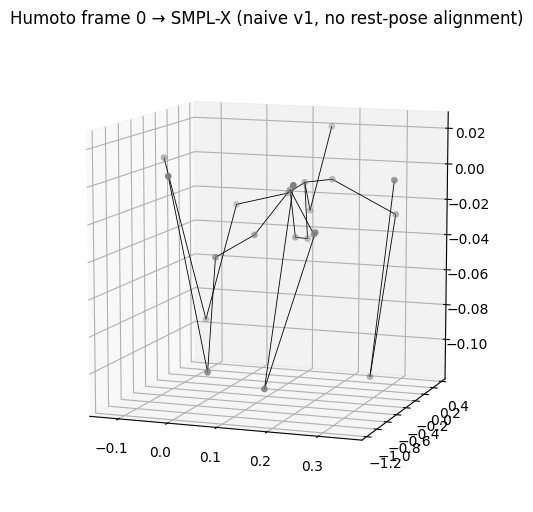

In [43]:
import numpy as np, torch
from scipy.spatial.transform import Rotation as Rot

# ─── Body-only Mixamo → SMPL-X joint correspondence ────────────────────────
# SMPL-X joint indices 0..21 (from your Experiment A dictionary).
# Each tuple: (smplx_idx, smplx_name, mixamo_bone_name)
BODY_CORR = [
    ( 0, 'pelvis',          'mixamorig:Hips'),         # → global_orient
    ( 1, 'left_hip',        'mixamorig:LeftUpLeg'),
    ( 2, 'right_hip',       'mixamorig:RightUpLeg'),
    ( 3, 'spine1',          'mixamorig:Spine'),
    ( 4, 'left_knee',       'mixamorig:LeftLeg'),
    ( 5, 'right_knee',      'mixamorig:RightLeg'),
    ( 6, 'spine2',          'mixamorig:Spine1'),
    ( 7, 'left_ankle',      'mixamorig:LeftFoot'),
    ( 8, 'right_ankle',     'mixamorig:RightFoot'),
    ( 9, 'spine3',          'mixamorig:Spine2'),
    (10, 'left_foot',       'mixamorig:LeftToeBase'),  # SMPL-X "foot" = ball-of-foot
    (11, 'right_foot',      'mixamorig:RightToeBase'),
    (12, 'neck',            'mixamorig:Neck'),
    (13, 'left_collar',     'mixamorig:LeftShoulder'), # ← Mixamo "Shoulder" = clavicle!
    (14, 'right_collar',    'mixamorig:RightShoulder'),
    (15, 'head',            'mixamorig:Head'),
    (16, 'left_shoulder',   'mixamorig:LeftArm'),      # ← Mixamo "Arm" = upper arm
    (17, 'right_shoulder',  'mixamorig:RightArm'),
    (18, 'left_elbow',      'mixamorig:LeftForeArm'),
    (19, 'right_elbow',     'mixamorig:RightForeArm'),
    (20, 'left_wrist',      'mixamorig:LeftHand'),
    (21, 'right_wrist',     'mixamorig:RightHand'),
]
# Unmapped on the Mixamo side (we ignore them for v1):
#   HeadTop_End, LeftToe_End, RightToe_End  — tip joints, no SMPL-X equivalent
#   all 30 finger bones (Thumb1..4, Index1..4, Middle1..4, Ring1..4, Pinky1..4)
#   We zero SMPL-X's hand_pose / face poses for v1.

Z_UP_TO_Y_UP = np.array([[1,0,0],[0,0,1],[0,-1,0]], dtype=np.float32)  # 3x3 (loc only)

def quat_wxyz_to_aa(q_wxyz):
    """Blender [w,x,y,z] quat -> axis-angle (3,)."""
    w, x, y, z = q_wxyz
    return Rot.from_quat([x, y, z, w]).as_rotvec().astype(np.float32)

def humoto_frame_to_smplx_pose(frame_dict):
    """
    Naive v1 conversion (no rest-pose alignment yet).
    Returns: global_orient (3,), body_pose (63,), trans (3,)
    """
    global_orient = np.zeros(3, dtype=np.float32)
    body_pose     = np.zeros(63, dtype=np.float32)
    trans         = np.zeros(3, dtype=np.float32)

    for smplx_idx, _, mx_name in BODY_CORR:
        entry = np.array(frame_dict[mx_name], dtype=np.float32)
        q_wxyz = entry[:4]
        aa = quat_wxyz_to_aa(q_wxyz)
        if smplx_idx == 0:
            # Hips: global_orient + trans (with z-up → y-up swap)
            # NOTE: we apply Z_UP_TO_Y_UP to the LOCATION here, but NOT yet to
            #       the quaternion — that's part of the alignment work for v2.
            global_orient[:] = aa
            trans[:] = Z_UP_TO_Y_UP @ entry[4:]
        else:
            body_pose[(smplx_idx-1)*3 : smplx_idx*3] = aa
    return global_orient, body_pose, trans

# ─── Convert frame 0 and render with SMPL-X ────────────────────────────────
go, bp, tr = humoto_frame_to_smplx_pose(arm[0])
print("global_orient:", np.round(go, 3))
print("trans:        ", np.round(tr, 3))
print("body_pose[:9]:", np.round(bp[:9], 3))  # first 3 joints' axis-angles

out = m(
    global_orient=torch.from_numpy(go)[None],
    body_pose    =torch.from_numpy(bp)[None],
    transl       =torch.from_numpy(tr)[None],
    betas        =torch.zeros(1, 16),
)
J = out.joints[0, :22].detach().numpy()

# Render the same way as Experiment A
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(5, 6))
ax = fig.add_subplot(111, projection='3d')
for k, p in enumerate(PARENTS):
    if p >= 0:
        ax.plot([J[p,0],J[k,0]],[J[p,1],J[k,1]],[J[p,2],J[k,2]], 'k-', lw=0.6)
ax.scatter(J[:,0], J[:,1], J[:,2], c='gray', s=15)
ax.set_title("Humoto frame 0 → SMPL-X (naive v1, no rest-pose alignment)")
ax.view_init(elev=10, azim=-70); ax.set_box_aspect((1,1,1))
plt.tight_layout(); plt.show()


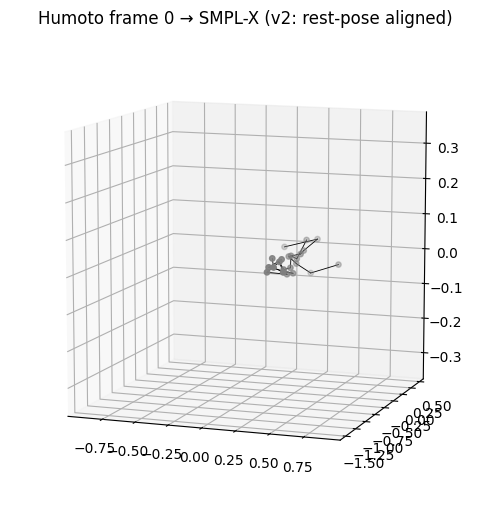

In [44]:
# Per-joint SMPL-X T-pose rest direction in SMPL-X's own y-up world frame.
# These describe which way the CHILD bone points in T-pose for each parent joint.
SMPLX_REST_DIR = {
    0:  ( 0,  1,  0),   # pelvis  (spine goes up)
    1:  ( 0, -1,  0),   # left_hip  -> leg goes down
    2:  ( 0, -1,  0),   # right_hip
    3:  ( 0,  1,  0),   # spine1
    4:  ( 0, -1,  0),   # left_knee -> shin down
    5:  ( 0, -1,  0),   # right_knee
    6:  ( 0,  1,  0),   # spine2
    7:  ( 0,  0,  1),   # left_ankle -> foot forward
    8:  ( 0,  0,  1),   # right_ankle
    9:  ( 0,  1,  0),   # spine3
    10: ( 0,  0,  1),   # left_foot (toe direction)
    11: ( 0,  0,  1),   # right_foot
    12: ( 0,  1,  0),   # neck
    13: ( 1,  0,  0),   # left_collar  -> shoulder out left  (+X = body's left in SMPL convention)
    14: (-1,  0,  0),   # right_collar
    15: ( 0,  1,  0),   # head
    16: ( 1,  0,  0),   # left_shoulder  -> upper arm out left
    17: (-1,  0,  0),   # right_shoulder
    18: ( 1,  0,  0),   # left_elbow
    19: (-1,  0,  0),   # right_elbow
    20: ( 1,  0,  0),   # left_wrist
    21: (-1,  0,  0),   # right_wrist
}
MIXAMO_REST_DIR_YUP = np.array([0, 1, 0], dtype=np.float32)   # +Y in y-up = "up"

def rot_align(v_from, v_to):
    """Shortest-arc rotation that takes v_from -> v_to. Returns scipy Rotation."""
    a = np.asarray(v_from, dtype=np.float64); a /= np.linalg.norm(a)
    b = np.asarray(v_to,   dtype=np.float64); b /= np.linalg.norm(b)
    c = np.cross(a, b); s = np.linalg.norm(c); d = np.dot(a, b)
    if s < 1e-9:
        if d > 0:   return Rot.identity()
        perp = np.array([1,0,0]) if abs(a[0]) < 0.9 else np.array([0,1,0])
        axis = np.cross(a, perp); axis /= np.linalg.norm(axis)
        return Rot.from_rotvec(np.pi * axis)
    return Rot.from_rotvec(np.arctan2(s, d) * (c / s))

# Pre-compute R_align[J] for every body joint
R_ALIGN = {
    j: rot_align(SMPLX_REST_DIR[j], MIXAMO_REST_DIR_YUP)
    for j in SMPLX_REST_DIR
}

# Reuse the T-pose bounds from Experiment A so the scale matches that plot
T_ref = m(betas=torch.zeros(1, 16)).joints[0, :22].detach().numpy()
lo, hi = T_ref.min(0) - 0.3, T_ref.max(0) + 0.3

def humoto_frame_to_smplx_pose_v2(frame_dict):
    """v2: per-joint rest-pose-aligned conversion."""
    global_orient = np.zeros(3, dtype=np.float32)
    body_pose     = np.zeros(63, dtype=np.float32)
    trans         = np.zeros(3, dtype=np.float32)

    for smplx_idx, _, mx_name in BODY_CORR:
        entry = np.array(frame_dict[mx_name], dtype=np.float32)
        w, x, y, z = entry[:4]
        Q_mx = Rot.from_quat([x, y, z, w])           # Mixamo rotation
        Q_sx = Q_mx * R_ALIGN[smplx_idx]             # rest-aligned (scipy: * is compose)
        aa   = Q_sx.as_rotvec().astype(np.float32)
        if smplx_idx == 0:
            global_orient[:] = aa
            trans[:] = Z_UP_TO_Y_UP @ entry[4:]
        else:
            body_pose[(smplx_idx-1)*3 : smplx_idx*3] = aa
    return global_orient, body_pose, trans

# Render frame 0 again with v2
go, bp, tr = humoto_frame_to_smplx_pose_v2(arm[0])
out = m(global_orient=torch.from_numpy(go)[None],
        body_pose    =torch.from_numpy(bp)[None],
        transl       =torch.from_numpy(tr)[None],
        betas        =torch.zeros(1, 16))
J = out.joints[0, :22].detach().numpy()

fig = plt.figure(figsize=(5, 6))
ax = fig.add_subplot(111, projection='3d')
for k, p in enumerate(PARENTS):
    if p >= 0:
        ax.plot([J[p,0],J[k,0]],[J[p,1],J[k,1]],[J[p,2],J[k,2]], 'k-', lw=0.6)
ax.scatter(J[:,0], J[:,1], J[:,2], c='gray', s=15)
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
ax.set_title("Humoto frame 0 → SMPL-X (v2: rest-pose aligned)")
ax.view_init(elev=10, azim=-70); ax.set_box_aspect((1,1,1))
plt.tight_layout(); plt.show()


Mixamo joints shape: (65, 3)
hips world pos (z-up): [ 0.12709458 -0.1059828   0.904223  ]
head world pos (z-up): [ 0.1387566  -0.10230415  1.3918525 ]
left wrist:            [ 0.3763308  -0.11498176  0.811036  ]
right wrist:           [-0.14364398 -0.14054048  0.8274676 ]


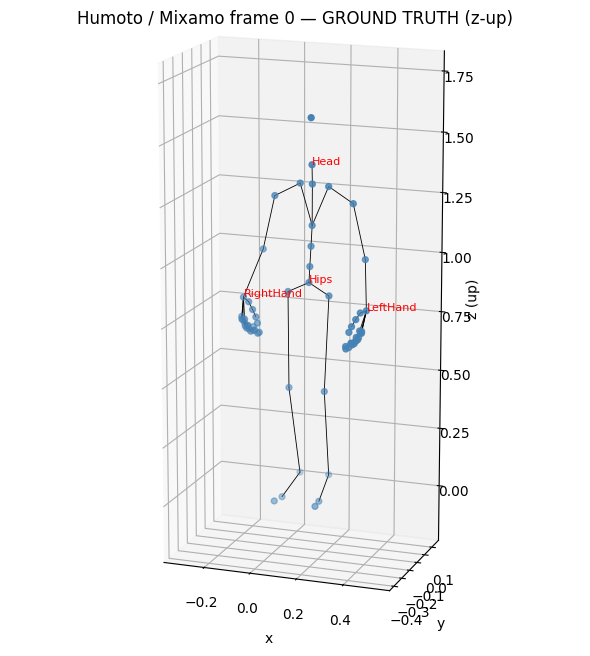

In [45]:
import sys, json
import numpy as np, torch
from scipy.spatial.transform import Rotation as Rot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Make humoto's code importable from this notebook
sys.path.insert(0, '/home/natcha/Downloads/projects/humoto')
from human_model.human_model import HumanModelDifferentiable

# We extracted pickles in Blender's z-up, up_bone layout → use the matching JSON
JSON_PATH = '/home/natcha/Downloads/projects/humoto/human_model/human_model_up_bone_zup.json'
mx_model = HumanModelDifferentiable(JSON_PATH, device='cpu')

# Convert pickle entries [w,x,y,z, lx,ly,lz] → dict of {bone_name: [1, 4, 4]} matrices
def humoto_frame_to_pose_params(frame_dict):
    pp = {}
    for bone, entry in frame_dict.items():
        e = np.asarray(entry, dtype=np.float32)
        w, x, y, z = e[:4]; lx, ly, lz = e[4:]
        R = Rot.from_quat([x, y, z, w]).as_matrix()           # 3x3
        M = np.eye(4, dtype=np.float32)
        M[:3, :3] = R
        M[:3,  3] = [lx, ly, lz]
        pp[bone] = torch.from_numpy(M).unsqueeze(0)            # [1, 4, 4]
    return pp

# Run FK on frame 0 → joint positions in Mixamo world (z-up)
pose_params = humoto_frame_to_pose_params(arm[0])
_, joint_positions = mx_model(pose_params)
# joint_positions is a dict {bone_name: tensor [1, 3]} → build (65, 3) array
JM = np.stack([joint_positions[b].detach().numpy()[0] for b in mx_model.bone_names], axis=0)
print(f"Mixamo joints shape: {JM.shape}")
print(f"hips world pos (z-up): {JM[0]}")        # expect ~ (0.13, 0.02, 0.99)
print(f"head world pos (z-up): {JM[mx_model.bone_names.index('mixamorig:Head')]}")
print(f"left wrist:            {JM[mx_model.bone_names.index('mixamorig:LeftHand')]}")
print(f"right wrist:           {JM[mx_model.bone_names.index('mixamorig:RightHand')]}")

# Bone connections from humoto's parent table
edges = [(i, p) for i, p in enumerate(mx_model.parents_idx) if p >= 0]

# Plot Mixamo skeleton in z-up
lo, hi = JM.min(0) - 0.2, JM.max(0) + 0.2
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
for (k, p) in edges:
    ax.plot([JM[p,0], JM[k,0]], [JM[p,1], JM[k,1]], [JM[p,2], JM[k,2]], 'k-', lw=0.6)
ax.scatter(JM[:,0], JM[:,1], JM[:,2], c='steelblue', s=18)
# label a few anchors so you can read the figure
for name in ['mixamorig:Hips','mixamorig:Head','mixamorig:LeftHand','mixamorig:RightHand']:
    i = mx_model.bone_names.index(name)
    ax.text(JM[i,0], JM[i,1], JM[i,2], name.replace('mixamorig:',''), fontsize=8, color='red')
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z (up)')
ax.set_title('Humoto / Mixamo frame 0 — GROUND TRUTH (z-up)')
ax.set_box_aspect((hi-lo))
ax.view_init(elev=15, azim=-70)
plt.tight_layout(); plt.show()


--- in y-up (after Z→Y conversion) ---
hips       y = 0.904   (expect ~0.99 m, standing pelvis)
head       y = 1.392   (expect > hips y)
left foot  y = 0.073   (expect near 0, ground)
left wrist xyz = [0.376 0.811 0.115]
right wrist xyz= [-0.144  0.827  0.141]
left  wrist x: 0.3763308
right wrist x: -0.14364398


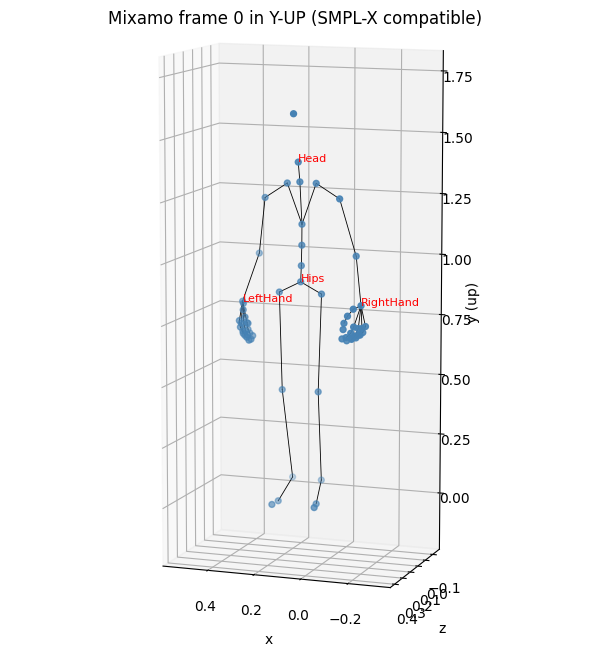

In [46]:
Z_TO_Y = np.array([[1, 0,  0],
                   [0, 0,  1],
                   [0,-1,  0]], dtype=np.float32)

JM_yup = JM @ Z_TO_Y.T          # (65, 3) → (65, 3)

# Verify: in y-up, the HIPS should now have y ≈ 0.99 (standing height),
# and head y should be higher than hips y. Wrists somewhere in between or lower.
hip_i   = mx_model.bone_names.index('mixamorig:Hips')
head_i  = mx_model.bone_names.index('mixamorig:Head')
lwri_i  = mx_model.bone_names.index('mixamorig:LeftHand')
rwri_i  = mx_model.bone_names.index('mixamorig:RightHand')
lfoot_i = mx_model.bone_names.index('mixamorig:LeftFoot')

print("--- in y-up (after Z→Y conversion) ---")
print(f"hips       y = {JM_yup[hip_i,1]:.3f}   (expect ~0.99 m, standing pelvis)")
print(f"head       y = {JM_yup[head_i,1]:.3f}   (expect > hips y)")
print(f"left foot  y = {JM_yup[lfoot_i,1]:.3f}   (expect near 0, ground)")
print(f"left wrist xyz = {np.round(JM_yup[lwri_i], 3)}")
print(f"right wrist xyz= {np.round(JM_yup[rwri_i], 3)}")
print("left  wrist x:", JM_yup[lwri_i, 0])
print("right wrist x:", JM_yup[rwri_i, 0])

# Render in y-up so it visually matches SMPL-X's convention
lo, hi = JM_yup.min(0) - 0.2, JM_yup.max(0) + 0.2
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
for (k, p) in edges:
    ax.plot([JM_yup[p,0], JM_yup[k,0]],
            [JM_yup[p,2], JM_yup[k,2]],
            [JM_yup[p,1], JM_yup[k,1]], 'k-', lw=0.6)
ax.scatter(JM_yup[:,0], JM_yup[:,2], JM_yup[:,1], c='steelblue', s=18)
for name in ['mixamorig:Hips','mixamorig:Head','mixamorig:LeftHand','mixamorig:RightHand']:
    i = mx_model.bone_names.index(name)
    ax.text(JM_yup[i,0], JM_yup[i,2], JM_yup[i,1], name.replace('mixamorig:',''),
            fontsize=8, color='red')
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
ax.set_xlabel('x'); ax.set_zlabel('y (up)'); ax.set_ylabel('z')
ax.set_title('Mixamo frame 0 in Y-UP (SMPL-X compatible)')
ax.set_box_aspect((hi - lo)[[0, 2, 1]])
ax.view_init(elev=10, azim=110)
plt.tight_layout(); plt.show()


In [47]:
# Spatula trajectory in z-up (objects weren't converted by the pickle load)
spatula_zup = np.array(objs['spatula'], dtype=np.float32)   # (T, 7) [w,x,y,z, lx,ly,lz]
spatula_pos_zup = spatula_zup[0, 4:]                          # frame-0 location
spatula_pos_yup = Z_TO_Y @ spatula_pos_zup

print(f"spatula  pos (y-up): {np.round(spatula_pos_yup, 3)}")
print(f"left  wrist (y-up):  {np.round(JM_yup[lwri_i], 3)}")
print(f"right wrist (y-up):  {np.round(JM_yup[rwri_i], 3)}")

d_left  = np.linalg.norm(spatula_pos_yup - JM_yup[lwri_i])
d_right = np.linalg.norm(spatula_pos_yup - JM_yup[rwri_i])
print(f"\ndist spatula ↔ LEFT  wrist: {d_left:.3f} m")
print(f"dist spatula ↔ RIGHT wrist: {d_right:.3f} m")
print(f"\n→ closer to: {'LEFT' if d_left < d_right else 'RIGHT'} wrist")


spatula  pos (y-up): [0.066 0.731 0.352]
left  wrist (y-up):  [0.376 0.811 0.115]
right wrist (y-up):  [-0.144  0.827  0.141]

dist spatula ↔ LEFT  wrist: 0.398 m
dist spatula ↔ RIGHT wrist: 0.313 m

→ closer to: RIGHT wrist


SMPL-X-indexed target (frame 0, y-up):
  [ 0] pelvis         ← mixamorig:Hips                  [0.127 0.904 0.106]
  [ 1] left_hip       ← mixamorig:LeftUpLeg             [0.216 0.858 0.114]
  [ 2] right_hip      ← mixamorig:RightUpLeg            [0.037 0.859 0.107]
  [ 3] spine1         ← mixamorig:Spine                 [0.128 0.969 0.097]
  [ 4] left_knee      ← mixamorig:LeftLeg               [0.201 0.457 0.124]
  [ 5] right_knee     ← mixamorig:RightLeg              [0.046 0.458 0.121]
  [ 6] spine2         ← mixamorig:Spine1                [0.129 1.051 0.087]
  [ 7] left_ankle     ← mixamorig:LeftFoot              [0.189 0.073 0.035]
  [ 8] right_ankle    ← mixamorig:RightFoot             [0.063 0.07  0.035]
  [ 9] spine3         ← mixamorig:Spine2                [0.131 1.136 0.079]
  [10] left_foot      ← mixamorig:LeftToeBase           [0.198 0.004 0.18 ]
  [11] right_foot     ← mixamorig:RightToeBase          [0.035 0.003 0.175]
  [12] neck           ← mixamorig:Neck           

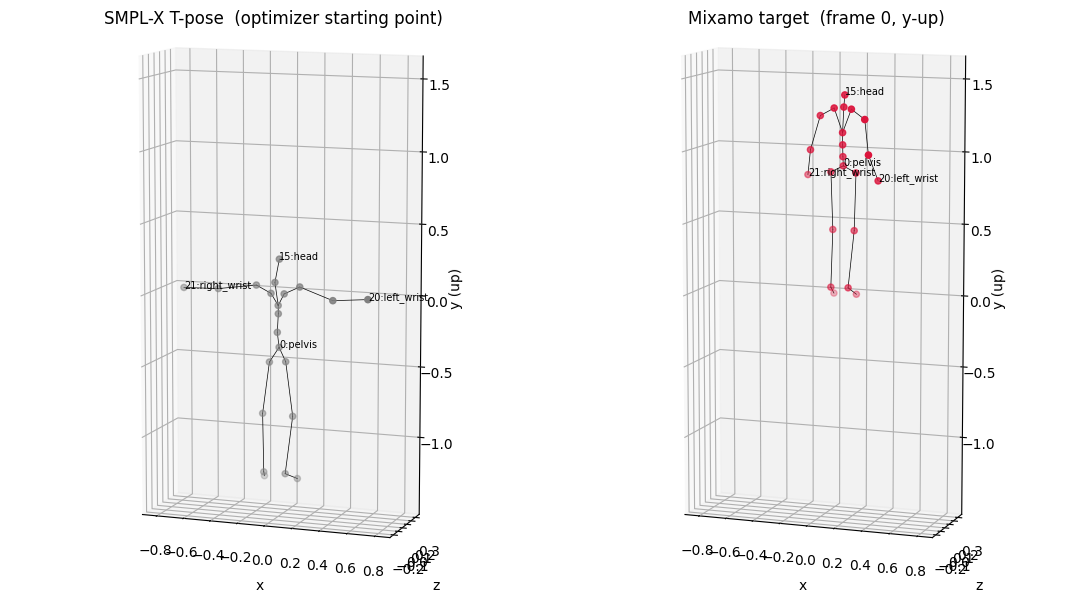

In [48]:
def build_position_target(JM_yup, body_corr, mx_bone_names):
    """
    Mixamo joints (65,3) in y-up  →  SMPL-X-indexed targets (22,3).
    target[smplx_idx] is the world position that SMPL-X joint smplx_idx
    should be moved to by the fitting optimizer.
    """
    target = np.zeros((22, 3), dtype=np.float32)
    for smplx_idx, _, mx_name in body_corr:
        mx_idx = mx_bone_names.index(mx_name)
        target[smplx_idx] = JM_yup[mx_idx]
    return target

target_22 = build_position_target(JM_yup, BODY_CORR, mx_model.bone_names)

# ─── Sanity prints ──────────────────────────────────────────────────────────
print("SMPL-X-indexed target (frame 0, y-up):")
for smplx_idx, smplx_name, mx_name in BODY_CORR:
    print(f"  [{smplx_idx:2d}] {smplx_name:14s} ← {mx_name:30s}  "
          f"{np.round(target_22[smplx_idx], 3)}")

print("\n--- expectations ---")
print(f"pelvis  y   = {target_22[0, 1]:.3f}    (≈ 0.99, standing pelvis height)")
print(f"head    y   = {target_22[15, 1]:.3f}    (must be > pelvis)")
print(f"l ankle y   = {target_22[7,  1]:.3f}    (≈ 0, on the floor)")
print(f"head > hips:        {target_22[15,1] > target_22[0,1]}")
print(f"l_wrist x > 0:      {target_22[20, 0] > 0}   (body's left at +x)")
print(f"r_wrist x < 0:      {target_22[21, 0] < 0}   (body's right at −x)")

# ─── Side-by-side: T-pose vs Mixamo target ─────────────────────────────────
T_smplx = m(betas=torch.zeros(1, 16)).joints[0, :22].detach().numpy()
both = np.vstack([T_smplx, target_22])
lo, hi = both.min(0) - 0.2, both.max(0) + 0.2
print(np.round(T_smplx, 3))

fig = plt.figure(figsize=(11, 6))
for i, (J, title, color) in enumerate([
        (T_smplx,   "SMPL-X T-pose  (optimizer starting point)", 'gray'),
        (target_22, "Mixamo target  (frame 0, y-up)",            'crimson'),
    ]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]], 'k-', lw=0.5)
    
    for j, joint_name in enumerate(BODY_NAMES):
        if joint_name in ['pelvis', 'head', 'left_wrist', 'right_wrist']:
            ax.text(J[j,0], J[j,2], J[j,1],
                    f"{j}:{joint_name}",
                    fontsize=7,
                    color='black')

    
    ax.scatter(J[:,0], J[:,2], J[:,1], c=color, s=20)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_xlabel('x'); ax.set_zlabel('y (up)'); ax.set_ylabel('z')
    ax.set_box_aspect((hi - lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.set_title(title)
plt.tight_layout(); plt.show()


In [49]:
import torch.optim as optim

# 21 parent→child edges from your PARENTS table
edges_21 = [(c, p) for c, p in enumerate(PARENTS) if p >= 0]

# Mixamo bone lengths (rigid → pose-invariant → frame 0 is fine)
target_lengths = np.array([
    np.linalg.norm(target_22[c] - target_22[p]) for c, p in edges_21
], dtype=np.float32)

print("Mixamo bone lengths (m):")
for (c, p), L in zip(edges_21, target_lengths):
    print(f"  {BODY_CORR[p][1]:14s} → {BODY_CORR[c][1]:14s}: {L:.3f}")

# ─── Fit betas (16,) ──────────────────────────────────────────────────────
betas      = torch.zeros(1, 16, requires_grad=True)
target_L_t = torch.from_numpy(target_lengths)
opt        = optim.Adam([betas], lr=0.05)

print("\nFitting betas...")
for step in range(200):
    J_t = m(betas=betas).joints[0, :22]
    pred_L = torch.stack([torch.norm(J_t[c] - J_t[p]) for c, p in edges_21])
    loss = ((pred_L - target_L_t) ** 2).mean() + 1e-3 * (betas ** 2).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 40 == 0 or step == 199:
        print(f"  step {step:3d}   loss = {loss.item():.6f}   "
              f"||betas|| = {betas.norm().item():.3f}")

betas_fit = betas.detach().clone()
print(f"\nFitted betas:\n{np.round(betas_fit[0].numpy(), 3)}")

# ─── Report bone-length residuals ─────────────────────────────────────────
T_fit       = m(betas=betas_fit).joints[0, :22].detach().numpy()
fit_lengths = np.array([np.linalg.norm(T_fit[c] - T_fit[p]) for c, p in edges_21])

print("\nBone-length residuals (target vs fitted):")
for (c, p), Lt, Lp in zip(edges_21, target_lengths, fit_lengths):
    err = 100 * (Lp - Lt) / Lt
    flag = '✓' if abs(err) < 5 else ('!' if abs(err) > 10 else '~')
    print(f"  {BODY_CORR[p][1]:14s} → {BODY_CORR[c][1]:14s}: "
          f"tgt={Lt:.3f}  fit={Lp:.3f}  ({err:+5.1f}%) {flag}")


Mixamo bone lengths (m):
  pelvis         → left_hip      : 0.101
  pelvis         → right_hip     : 0.101
  pelvis         → spine1        : 0.065
  left_hip       → left_knee     : 0.402
  right_hip      → right_knee    : 0.402
  spine1         → spine2        : 0.083
  left_knee      → left_ankle    : 0.395
  right_knee     → right_ankle   : 0.397
  spine2         → spine3        : 0.085
  left_ankle     → left_foot     : 0.161
  right_ankle    → right_foot    : 0.157
  spine3         → neck          : 0.174
  spine3         → left_collar   : 0.177
  spine3         → right_collar  : 0.177
  neck           → head          : 0.083
  left_collar    → left_shoulder : 0.121
  right_collar   → right_shoulder: 0.120
  left_shoulder  → left_elbow    : 0.243
  right_shoulder → right_elbow   : 0.244
  left_elbow     → left_wrist    : 0.213
  right_elbow    → right_wrist   : 0.213

Fitting betas...


  step   0   loss = 0.001571   ||betas|| = 0.200
  step  40   loss = 0.001563   ||betas|| = 0.087
  step  80   loss = 0.001563   ||betas|| = 0.085
  step 120   loss = 0.001563   ||betas|| = 0.085
  step 160   loss = 0.001563   ||betas|| = 0.085
  step 199   loss = 0.001563   ||betas|| = 0.085

Fitted betas:
[-0.075  0.02   0.009  0.019 -0.006  0.005  0.002  0.005 -0.02   0.
  0.01  -0.008 -0.008  0.005  0.002  0.001]

Bone-length residuals (target vs fitted):
  pelvis         → left_hip      : tgt=0.101  fit=0.112  (+11.6%) !
  pelvis         → right_hip     : tgt=0.101  fit=0.123  (+22.3%) !
  pelvis         → spine1        : tgt=0.065  fit=0.113  (+72.9%) !
  left_hip       → left_knee     : tgt=0.402  fit=0.381  ( -5.2%) ~
  right_hip      → right_knee    : tgt=0.402  fit=0.364  ( -9.4%) ~
  spine1         → spine2        : tgt=0.083  fit=0.131  (+58.2%) !
  left_knee      → left_ankle    : tgt=0.395  fit=0.405  ( +2.5%) ✓
  right_knee     → right_ankle   : tgt=0.397  fit=0.409  ( +

In [50]:
betas = torch.zeros(1, 16, requires_grad=True)
log_scale = torch.zeros(1, requires_grad=True)

target_L_t = torch.from_numpy(target_lengths)
opt = optim.Adam([betas, log_scale], lr=0.03)

for step in range(300):
    J_t = m(betas=betas).joints[0, :22]
    pred_L = torch.stack([torch.norm(J_t[c] - J_t[p]) for c, p in edges_21])

    scale = torch.exp(log_scale)
    pred_L_scaled = scale * pred_L

    rel = (pred_L_scaled - target_L_t) / target_L_t.clamp_min(1e-6)
    loss_data = (rel ** 2).mean()

    # loss_data = ((pred_L_scaled - target_L_t) ** 2).mean()
    loss_reg = 1e-3 * (betas ** 2).mean() + 1e-3 * (log_scale ** 2).mean()
    loss = loss_data + loss_reg

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 40 == 0 or step == 299:
        print(
            f"step {step:3d} loss={loss.item():.6f} "
            f"scale={scale.item():.4f} ||betas||={betas.norm().item():.3f}"
        )

scale_fit = torch.exp(log_scale.detach()).item()
T_fit = m(betas=betas_fit).joints[0, :22].detach().numpy()
fit_lengths = scale_fit * np.array([
    np.linalg.norm(T_fit[c] - T_fit[p]) for c, p in edges_21
])

print("\nBone-length residuals (target vs fitted):")
for (c, p), Lt, Lp in zip(edges_21, target_lengths, fit_lengths):
    err = 100 * (Lp - Lt) / Lt
    flag = '✓' if abs(err) < 5 else ('!' if abs(err) > 10 else '~')
    print(f"  {BODY_CORR[p][1]:14s} → {BODY_CORR[c][1]:14s}: "
          f"tgt={Lt:.3f}  fit={Lp:.3f}  ({err:+5.1f}%) {flag}")


step   0 loss=0.121911 scale=1.0000 ||betas||=0.120
step  40 loss=0.071055 scale=0.8513 ||betas||=4.103
step  80 loss=0.058883 scale=0.8858 ||betas||=7.346
step 120 loss=0.051786 scale=0.9132 ||betas||=9.791
step 160 loss=0.047638 scale=0.9495 ||betas||=11.559
step 200 loss=0.045123 scale=0.9917 ||betas||=12.802
step 240 loss=0.043436 scale=1.0384 ||betas||=13.654
step 280 loss=0.042144 scale=1.0890 ||betas||=14.237
step 299 loss=0.041607 scale=1.1144 ||betas||=14.451

Bone-length residuals (target vs fitted):
  pelvis         → left_hip      : tgt=0.101  fit=0.125  (+24.6%) !
  pelvis         → right_hip     : tgt=0.101  fit=0.137  (+36.5%) !
  pelvis         → spine1        : tgt=0.065  fit=0.126  (+92.9%) !
  left_hip       → left_knee     : tgt=0.402  fit=0.425  ( +5.8%) ~
  right_hip      → right_knee    : tgt=0.402  fit=0.406  ( +1.0%) ✓
  spine1         → spine2        : tgt=0.083  fit=0.147  (+76.6%) !
  left_knee      → left_ankle    : tgt=0.395  fit=0.452  (+14.4%) !
  right_

In [51]:
# Edges to exclude from beta fitting (semantically incompatible between Mixamo and SMPL-X)
SKIP_EDGES = {(15, 12), (13, 9), (14, 9)}   # neck→head, spine3→l_collar, spine3→r_collar

edges_to_fit = [(c, p) for (c, p) in edges_21 if (c, p) not in SKIP_EDGES]
target_L = np.array([np.linalg.norm(target_22[c] - target_22[p])
                     for c, p in edges_to_fit], dtype=np.float32)
target_L_t = torch.from_numpy(target_L)

betas = torch.zeros(1, 16, requires_grad=True)
opt   = optim.Adam([betas], lr=0.05)

print("Fitting betas v2 (relative loss, weak reg, skip 3 incompatible edges)...")
for step in range(800):
    J_t    = m(betas=betas).joints[0, :22]
    pred_L = torch.stack([torch.norm(J_t[c] - J_t[p]) for c, p in edges_to_fit])
    # Relative error: every bone matters equally
    rel    = pred_L / target_L_t - 1.0
    loss   = (rel ** 2).mean() + 1e-5 * (betas ** 2).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0 or step == 799:
        print(f"  step {step:3d}  loss={loss.item():.6f}  "
              f"||betas||={betas.norm().item():.3f}  "
              f"max|rel|={rel.abs().max().item()*100:.1f}%")

betas_fit = betas.detach().clone()
print(f"\nFitted betas:\n{np.round(betas_fit[0].numpy(), 3)}")

# Residuals on the 18 fitted edges (skipping the 3 incompatible)
T_fit = m(betas=betas_fit).joints[0, :22].detach().numpy()
print("\nResiduals on fitted edges:")
for (c, p), Lt in zip(edges_to_fit, target_L):
    Lp  = np.linalg.norm(T_fit[c] - T_fit[p])
    err = 100 * (Lp - Lt) / Lt
    flag = '✓' if abs(err) < 5 else ('!' if abs(err) > 15 else '~')
    print(f"  {BODY_CORR[p][1]:14s} → {BODY_CORR[c][1]:14s}: "
          f"tgt={Lt:.3f}  fit={Lp:.3f}  ({err:+5.1f}%) {flag}")


Fitting betas v2 (relative loss, weak reg, skip 3 incompatible edges)...
  step   0  loss=0.066215  ||betas||=0.200  max|rel|=73.6%
  step 100  loss=0.014076  ||betas||=13.082  max|rel|=21.3%
  step 200  loss=0.010106  ||betas||=16.757  max|rel|=16.5%
  step 300  loss=0.008554  ||betas||=18.899  max|rel|=13.7%
  step 400  loss=0.007897  ||betas||=20.088  max|rel|=11.9%
  step 500  loss=0.007588  ||betas||=20.725  max|rel|=10.8%
  step 600  loss=0.007431  ||betas||=21.086  max|rel|=10.1%
  step 700  loss=0.007349  ||betas||=21.302  max|rel|=9.7%
  step 799  loss=0.007306  ||betas||=21.437  max|rel|=9.5%

Fitted betas:
[-1.3100e+00  6.0000e-03  4.8800e-01  2.0110e+00  5.7850e+00  3.8800e-01
 -1.2270e+00  2.1000e-01 -9.7350e+00  2.5540e+00  1.1690e+00 -3.6250e+00
 -1.2661e+01  1.0121e+01 -1.1060e+00  6.2140e+00]

Residuals on fitted edges:
  pelvis         → left_hip      : tgt=0.101  fit=0.097  ( -3.6%) ✓
  pelvis         → right_hip     : tgt=0.101  fit=0.104  ( +3.1%) ✓
  pelvis       

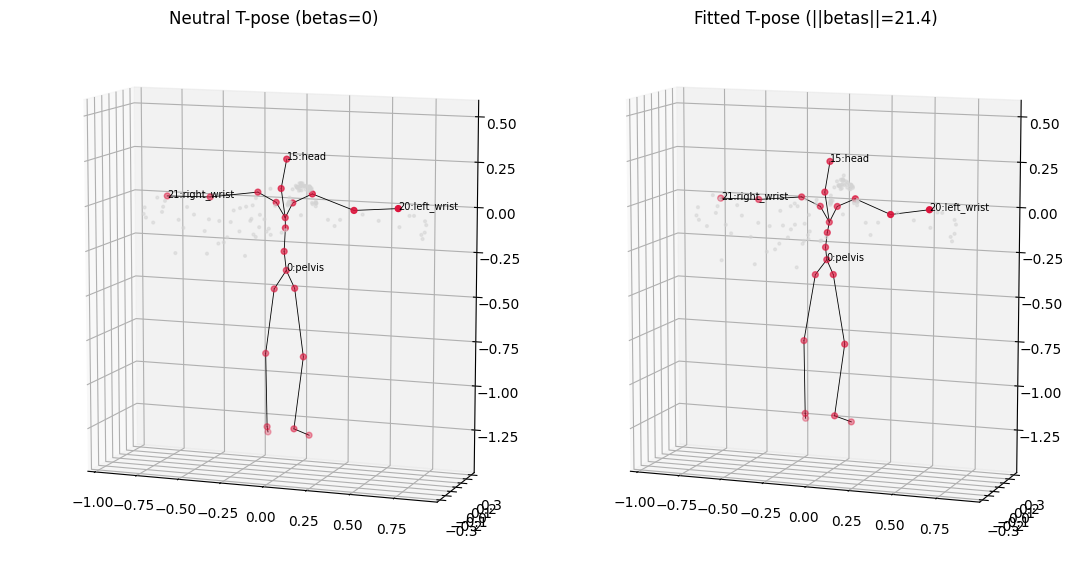

In [52]:
# Render the fitted T-pose body (no rotations, just betas applied) as a 3D scatter
# AND a downsampled mesh-vertex point cloud so you can see surface shape
out_fit  = m(betas=betas_fit)
J_fit    = out_fit.joints[0, :22].detach().numpy()
V_fit    = out_fit.vertices[0].detach().numpy()
V_sample = V_fit[::100]   # downsample 10475 vertices → ~104 points

out_neutral = m(betas=torch.zeros(1, 16))
J_neutral   = out_neutral.joints[0, :22].detach().numpy()
V_neutral   = out_neutral.vertices[0].detach().numpy()[::100]

both = np.vstack([J_fit, J_neutral, V_sample, V_neutral])
lo, hi = both.min(0) - 0.15, both.max(0) + 0.15

fig = plt.figure(figsize=(11, 6))
for i, (J, V, title) in enumerate([
        (J_neutral, V_neutral, "Neutral T-pose (betas=0)"),
        (J_fit,     V_sample,  f"Fitted T-pose (||betas||={betas_fit.norm():.1f})"),
    ]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(V[:,0], V[:,1], V[:,2], c='lightgray', s=4, alpha=0.5)  # body surface
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]], 'k-', lw=0.6)
    
    for j, joint_name in enumerate(BODY_NAMES):
        if joint_name in ['pelvis', 'head', 'left_wrist', 'right_wrist']:
            ax.text(J[j,0], J[j,2], J[j,1],
                    f"{j}:{joint_name}",
                    fontsize=7,
                    color='black')
            
    ax.scatter(J[:,0], J[:,2], J[:,1], c='crimson', s=18)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.set_title(title)
plt.tight_layout(); plt.show()


Joint-position β-fit on frame 0...
  step   0  loss=0.01721  mean=14.2cm  max=64.2cm  ||β||=0.20


  step  60  loss=0.00059  mean=3.3cm  max=7.3cm  ||β||=0.86
  step 120  loss=0.00056  mean=3.1cm  max=7.6cm  ||β||=0.88
  step 180  loss=0.00055  mean=3.1cm  max=7.5cm  ||β||=0.87
  step 240  loss=0.00055  mean=3.1cm  max=7.5cm  ||β||=0.87
  step 300  loss=0.00055  mean=3.1cm  max=7.5cm  ||β||=0.87
  step 360  loss=0.00055  mean=3.1cm  max=7.5cm  ||β||=0.87
  step 420  loss=0.00055  mean=3.1cm  max=7.5cm  ||β||=0.87
  step 480  loss=0.00055  mean=3.1cm  max=7.4cm  ||β||=0.87
  step 540  loss=0.00055  mean=3.1cm  max=7.4cm  ||β||=0.87
  step 599  loss=0.00055  mean=3.1cm  max=7.4cm  ||β||=0.86

=== β-fit complete ===
||β|| = 0.86    (regularized → should be 2–6 range)
frame 0 trans          = [0.121 1.234 0.118]
frame 0 global_orient  = [-0.05  -0.065  0.023]
frozen betas:
[-0.827  0.132 -0.135  0.081  0.035  0.078 -0.017 -0.003 -0.074 -0.008
  0.041 -0.045 -0.038  0.015  0.007  0.007]


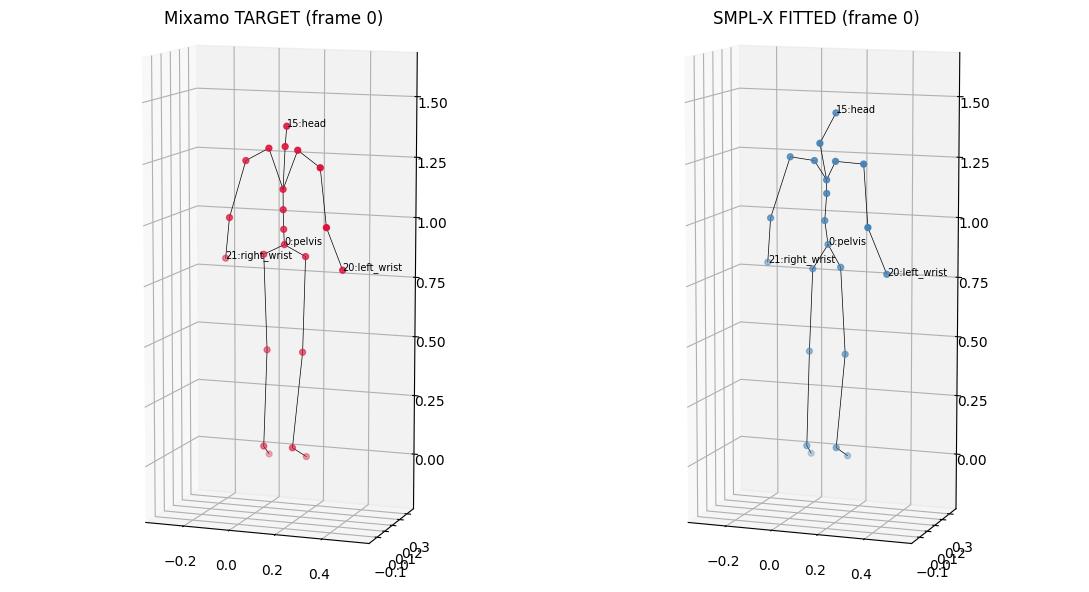

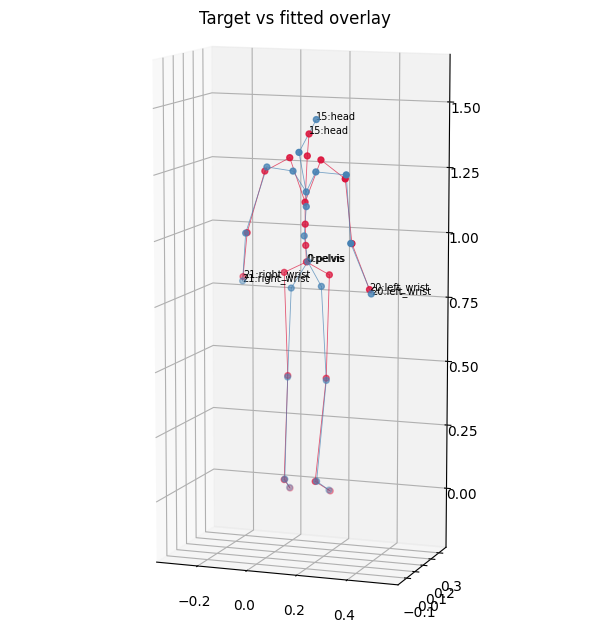

In [53]:
# ─── Joint-position β-fit on frame 0 (β + pose + trans jointly) ────────────
# After this, freeze betas_fit and only re-fit pose+trans for other frames.

target_t = torch.from_numpy(target_22)                            # (22, 3) y-up

# Warm-start trans by aligning pelvises (neutral SMPL-X pelvis vs Mixamo pelvis)
pelvis_neutral = m(betas=torch.zeros(1, 16)).joints[0, 0].detach()
trans_init     = (target_t[0] - pelvis_neutral)

# Optimization variables
betas         = torch.zeros(1, 16, requires_grad=True)
global_orient = torch.zeros(1, 3,  requires_grad=True)
body_pose     = torch.zeros(1, 63, requires_grad=True)
trans         = trans_init.unsqueeze(0).clone().requires_grad_(True)

opt = optim.Adam([betas, global_orient, body_pose, trans], lr=0.05)

print("Joint-position β-fit on frame 0...")
for step in range(600):
    out  = m(global_orient=global_orient, body_pose=body_pose,
             transl=trans, betas=betas)
    pred = out.joints[0, :22]                                    # (22, 3)

    pos_loss   = ((pred - target_t) ** 2).mean()                 # main objective
    beta_prior = (betas ** 2).mean()                             # ||β||² keeps shape sane
    pose_prior = (body_pose ** 2).mean()                         # discourage extreme angles

    loss = pos_loss + 0.001 * beta_prior + 0.0005 * pose_prior

    opt.zero_grad(); loss.backward(); opt.step()

    if step % 60 == 0 or step == 599:
        joint_err = (pred - target_t).norm(dim=1)
        print(f"  step {step:3d}  loss={loss.item():.5f}  "
              f"mean={joint_err.mean().item()*100:.1f}cm  "
              f"max={joint_err.max().item()*100:.1f}cm  "
              f"||β||={betas.norm().item():.2f}")

# Freeze
betas_fit            = betas.detach().clone()
frame0_global_orient = global_orient.detach().clone()
frame0_body_pose     = body_pose.detach().clone()
frame0_trans         = trans.detach().clone()

print(f"\n=== β-fit complete ===")
print(f"||β|| = {betas_fit.norm().item():.2f}    (regularized → should be 2–6 range)")
print(f"frame 0 trans          = {np.round(frame0_trans[0].numpy(), 3)}")
print(f"frame 0 global_orient  = {np.round(frame0_global_orient[0].numpy(), 3)}")
print(f"frozen betas:\n{np.round(betas_fit[0].numpy(), 3)}")

# ─── Visualize: target vs fitted overlay ──────────────────────────────────
# pred_final = pred.detach().numpy()
with torch.no_grad():
    pred_final = m(
        global_orient=frame0_global_orient,
        body_pose=frame0_body_pose,
        transl=frame0_trans,
        betas=betas_fit,
    ).joints[0, :22].detach().numpy()

both = np.vstack([target_22, pred_final])
lo, hi = both.min(0) - 0.2, both.max(0) + 0.2

fig = plt.figure(figsize=(11, 6))

# Side by side
for i, (J, title, c) in enumerate([
        (target_22,  "Mixamo TARGET (frame 0)", 'crimson'),
        (pred_final, "SMPL-X FITTED (frame 0)", 'steelblue'),
    ]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]], 'k-', lw=0.5)
    for j, joint_name in enumerate(BODY_NAMES):
        if joint_name in ['pelvis', 'head', 'left_wrist', 'right_wrist']:
            ax.text(J[j,0], J[j,2], J[j,1],
                    f"{j}:{joint_name}",
                    fontsize=7,
                    color='black')
            
    ax.scatter(J[:,0], J[:,2], J[:,1], c=c, s=18) 
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.set_title(title)
plt.tight_layout(); plt.show()

# Overlay in one axes
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
for J, lbl, c in [(target_22,  'target', 'crimson'),
                  (pred_final, 'fitted', 'steelblue')]:
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]],
                    '-', color=c, lw=0.6, alpha=0.7)

    for j, joint_name in enumerate(BODY_NAMES):
        if joint_name in ['pelvis', 'head', 'left_wrist', 'right_wrist']:
            ax.text(J[j,0], J[j,2], J[j,1],
                    f"{j}:{joint_name}",
                    fontsize=7,
                    color='black')
            
    ax.scatter(J[:,0], J[:,2], J[:,1], c=c, s=18)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.set_title("Target vs fitted overlay")
plt.tight_layout(); plt.show()


In [54]:
hp = frame0_body_pose[0, 42:45].numpy()   # joint 15 (head) axis-angle
np_ = frame0_body_pose[0, 33:36].numpy()  # joint 12 (neck)
print(f"head  body_pose: {np.round(hp,3)}   ||axis-angle||={np.linalg.norm(hp)*180/np.pi:.1f}°")
print(f"neck  body_pose: {np.round(np_,3)}  ||axis-angle||={np.linalg.norm(np_)*180/np.pi:.1f}°")


head  body_pose: [0. 0. 0.]   ||axis-angle||=0.0°
neck  body_pose: [ 0.677 -0.092 -0.076]  ||axis-angle||=39.4°


In [55]:
from tqdm import tqdm

T = len(arm)
print(f"Pre-computing Mixamo joint positions for all {T} frames...")

# Pre-compute all target_22 arrays (T, 22, 3) in y-up
all_targets = np.zeros((T, 22, 3), dtype=np.float32)
for t in tqdm(range(T)):
    pose_params_t = humoto_frame_to_pose_params(arm[t])
    with torch.no_grad():
        _, jp_t = mx_model(pose_params_t)
    JM_t     = np.stack([jp_t[b].numpy()[0] for b in mx_model.bone_names], axis=0)
    JM_yup_t = JM_t @ Z_TO_Y.T
    all_targets[t] = build_position_target(JM_yup_t, BODY_CORR, mx_model.bone_names)

print("Targets ready.")

# ─── Per-frame fitting loop (β frozen) ─────────────────────────────────────
fitted_go = np.zeros((T, 3),  dtype=np.float32)
fitted_bp = np.zeros((T, 63), dtype=np.float32)
fitted_tr = np.zeros((T, 3),  dtype=np.float32)

# Seed frame 0 from our earlier fit
fitted_go[0] = frame0_global_orient[0].numpy()
fitted_bp[0] = frame0_body_pose[0].numpy()
fitted_tr[0] = frame0_trans[0].numpy()

errors_per_frame = np.zeros(T, dtype=np.float32)
errors_per_frame[0] = 0.031   # mean err from frame-0 fit

print(f"\nFitting {T-1} frames with warm-start...")
for t in tqdm(range(1, T)):
    # Warm-start from previous frame's solution
    go_var = torch.from_numpy(fitted_go[t-1:t]).clone().requires_grad_(True)
    bp_var = torch.from_numpy(fitted_bp[t-1:t]).clone().requires_grad_(True)
    tr_var = torch.from_numpy(fitted_tr[t-1:t]).clone().requires_grad_(True)

    target_t = torch.from_numpy(all_targets[t])
    bp_prev  = torch.from_numpy(fitted_bp[t-1:t])

    opt = optim.Adam([go_var, bp_var, tr_var], lr=0.03)

    for step in range(80):
        out  = m(global_orient=go_var, body_pose=bp_var, transl=tr_var, betas=betas_fit)
        pred = out.joints[0, :22]
        pos_loss    = ((pred - target_t) ** 2).mean()
        pose_prior  = (bp_var ** 2).mean()
        smoothness  = ((bp_var - bp_prev) ** 2).mean()   # discourage jitter
        loss = pos_loss + 0.0005 * pose_prior + 0.01 * smoothness
        opt.zero_grad(); loss.backward(); opt.step()

    fitted_go[t] = go_var.detach()[0].numpy()
    fitted_bp[t] = bp_var.detach()[0].numpy()
    fitted_tr[t] = tr_var.detach()[0].numpy()
    with torch.no_grad():
        errors_per_frame[t] = (pred - target_t).norm(dim=1).mean().item()

print(f"\n=== Fitting complete ===")
print(f"Mean error across all frames: {errors_per_frame.mean()*100:.2f} cm")
print(f"Max  error across all frames: {errors_per_frame.max()*100:.2f} cm")
print(f"Worst frame: {errors_per_frame.argmax()}  (err = {errors_per_frame.max()*100:.2f} cm)")


Pre-computing Mixamo joint positions for all 293 frames...


  3%|▎         | 10/293 [00:00<00:02, 94.55it/s]

100%|██████████| 293/293 [00:03<00:00, 97.43it/s] 


Targets ready.

Fitting 292 frames with warm-start...


100%|██████████| 292/292 [04:28<00:00,  1.09it/s]


=== Fitting complete ===
Mean error across all frames: 2.99 cm
Max  error across all frames: 3.10 cm
Worst frame: 0  (err = 3.10 cm)


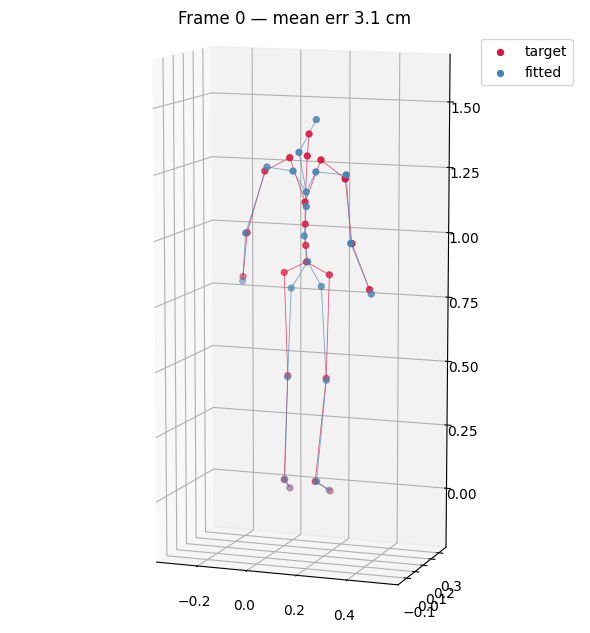

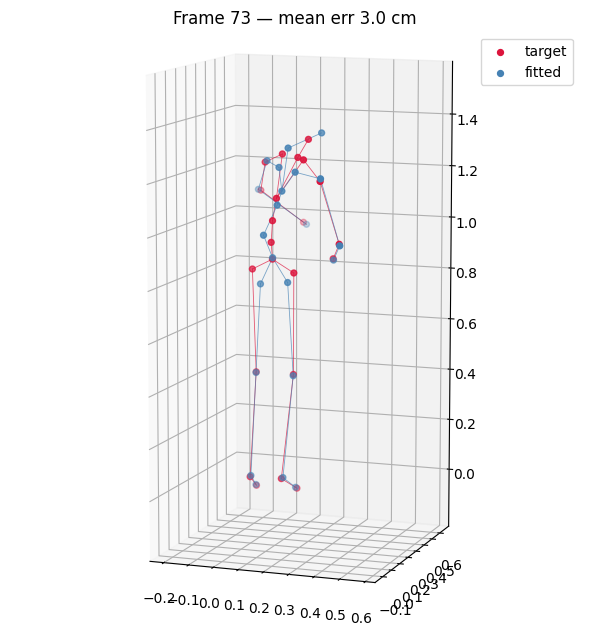

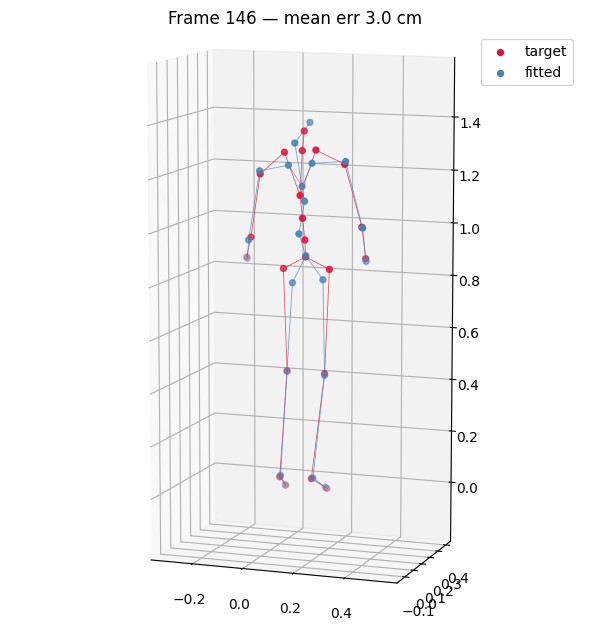

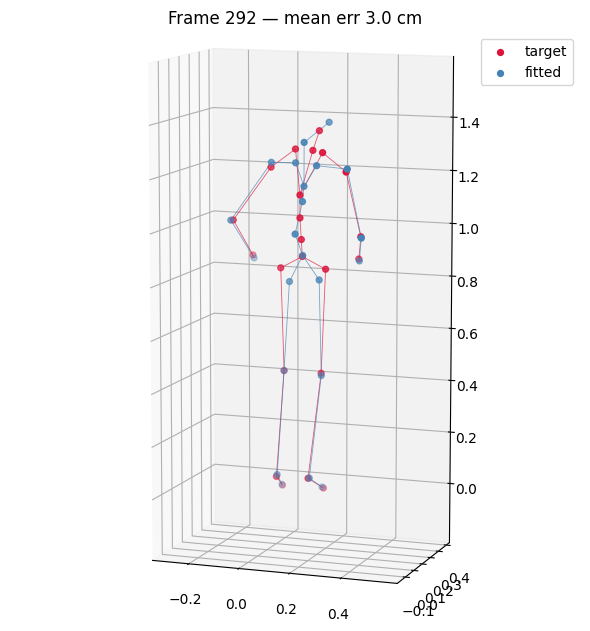

In [56]:
def render_frame(t):
    with torch.no_grad():
        out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
                body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
                transl       =torch.from_numpy(fitted_tr[t:t+1]),
                betas        =betas_fit)
        pred = out.joints[0, :22].numpy()
    target = all_targets[t]
    both = np.vstack([target, pred])
    lo, hi = both.min(0) - 0.2, both.max(0) + 0.2

    fig = plt.figure(figsize=(6, 7))
    ax = fig.add_subplot(111, projection='3d')
    for J, lbl, c in [(target, 'target', 'crimson'),
                      (pred,   'fitted', 'steelblue')]:
        for k, p in enumerate(PARENTS):
            if p >= 0:
                ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]],
                        '-', color=c, lw=0.6, alpha=0.7)
        ax.scatter(J[:,0], J[:,2], J[:,1], c=c, s=18, label=lbl)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.legend(); ax.set_title(f"Frame {t} — mean err {errors_per_frame[t]*100:.1f} cm")
    plt.tight_layout(); plt.show()

# Worst frame and a couple of typical ones
render_frame(int(errors_per_frame.argmax()))
render_frame(T // 4)
render_frame(T // 2)
render_frame(T - 1)


In [57]:
import os

# Assemble the 156-D pose vector InterAct expects:
#   [0:3]   global_orient
#   [3:66]  body_pose
#   [66:111] left_hand_pose  (zero for v1)
#   [111:156] right_hand_pose (zero for v1)
poses = np.concatenate([
    fitted_go,                             # (T, 3)
    fitted_bp,                             # (T, 63)
    np.zeros((T, 90), dtype=np.float32),   # 45 + 45 hand
], axis=1)                                 # → (T, 156)

# Save in the InterAct convention you saw in cell #1 of data_demo
seq_name = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
out_dir = f'/media/natcha/Natcha_T7/InterAct_workspace/humoto_smplx/{seq_name}'
os.makedirs(out_dir, exist_ok=True)

np.savez(
    os.path.join(out_dir, 'human.npz'),
    poses=poses.astype(np.float32),
    betas=betas_fit[0].numpy().astype(np.float32),   # (16,)
    trans=fitted_tr.astype(np.float32),              # (T, 3)
    gender='neutral',
)

print(f"Saved: {out_dir}/human.npz")
print(f"  poses: {poses.shape}     (T, 156)  — matches InterAct convention")
print(f"  betas: {betas_fit[0].numpy().shape}     (16,)")
print(f"  trans: {fitted_tr.shape}     (T, 3)")
print(f"  gender: neutral")


Saved: /media/natcha/Natcha_T7/InterAct_workspace/humoto_smplx/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244/human.npz
  poses: (293, 156)     (T, 156)  — matches InterAct convention
  betas: (16,)     (16,)
  trans: (293, 3)     (T, 3)
  gender: neutral


In [58]:
with np.load(os.path.join(out_dir, 'human.npz'), allow_pickle=True) as f:
    print("keys:", list(f.keys()))
    print("poses shape:", f['poses'].shape)
    print("betas shape:", f['betas'].shape)
    print("trans shape:", f['trans'].shape)
    print("gender:", str(f['gender']))


keys: ['poses', 'betas', 'trans', 'gender']
poses shape: (293, 156)
betas shape: (16,)
trans shape: (293, 3)
gender: neutral


In [59]:
import numpy as np, os

seq = 'sub1_clothesstand_000'
seq_dir = f'/home/natcha/Downloads/projects/InterAct/data/omomo/sequences_canonical/{seq}'

regenerated = np.load(os.path.join(seq_dir, 'motion.npy'))
shipped     = np.load('./tmp/shipped_motion.npy')

print(f"shipped     shape: {shipped.shape}")
print(f"regenerated shape: {regenerated.shape}")
assert shipped.shape == regenerated.shape, "Shape mismatch — different processing version"

diff = np.abs(regenerated - shipped)
print(f"\nmean abs diff:  {diff.mean():.6f}")
print(f"max  abs diff:  {diff.max():.6f}")
print(f"per-block max diffs:")
print(f"  markers   (dims 0:231): {diff[:, 0:231].max():.6f}")
print(f"  marker v  (dims 231:462): {diff[:, 231:462].max():.6f}")
print(f"  foot cont (dims 462:476): {diff[:, 462:476].max():.6f}")
print(f"  obj rep   (dims 476:962): {diff[:, 476:962].max():.6f}")

# Also cross-check against the shipped markers.npy directly
markers_from_motion   = regenerated[:, :231].reshape(-1, 77, 3)
markers_shipped       = np.load(os.path.join(seq_dir, 'markers.npy'))
print(f"\nmarkers cross-check:")
print(f"  shipped markers.npy shape: {markers_shipped.shape}")
print(f"  motion[:,:231]→(T,77,3):   {markers_from_motion.shape}")
print(f"  mean abs diff:             {np.abs(markers_from_motion - markers_shipped).mean():.6f}")


shipped     shape: (165, 962)
regenerated shape: (165, 962)

mean abs diff:  0.000000
max  abs diff:  0.000000
per-block max diffs:
  markers   (dims 0:231): 0.000000
  marker v  (dims 231:462): 0.000000
  foot cont (dims 462:476): 0.000000
  obj rep   (dims 476:962): 0.000000


FileNotFoundError: [Errno 2] No such file or directory: '/home/natcha/Downloads/projects/InterAct/data/omomo/sequences_canonical/sub1_clothesstand_000/markers.npy'

In [65]:
import os, numpy as np
from scipy.spatial.transform import Rotation as Rot

OBJ_NAME = 'spatula'
SEQ_NAME = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
out_seq_dir = f'/home/natcha/Downloads/projects/InterAct/data/humoto/sequences_canonical/{SEQ_NAME}'
out_obj_dir = f'/home/natcha/Downloads/projects/InterAct/data/humoto/objects/{OBJ_NAME}'
os.makedirs(out_seq_dir, exist_ok=True)
os.makedirs(out_obj_dir, exist_ok=True)

# 1. Move/copy your human.npz into the canonical layout
import shutil
shutil.copy(
    f'/media/natcha/Natcha_T7/InterAct_workspace/humoto_smplx/{SEQ_NAME}/human.npz',
    f'{out_seq_dir}/human.npz')

# 2. Build object.npz from the pickle data (objs[OBJ_NAME] is (T, 7) in z-up)
spatula_zup = np.array(objs[OBJ_NAME], dtype=np.float32)              # (T, 7) [w,x,y,z, lx,ly,lz]

# Translation: z-up → y-up
spatula_trans_yup = spatula_zup[:, 4:] @ Z_TO_Y.T                     # (T, 3)

# Rotation: z-up → y-up. Apply Z_TO_Y rotation to each frame's orientation.
Z_TO_Y_R = Rot.from_matrix(Z_TO_Y.astype(np.float64))
quat_zup_xyzw = spatula_zup[:, [1, 2, 3, 0]]                          # reorder w,x,y,z → x,y,z,w (scipy)
obj_rot_zup   = Rot.from_quat(quat_zup_xyzw)
obj_rot_yup   = Z_TO_Y_R * obj_rot_zup                                # apply coord-frame change
obj_angles    = obj_rot_yup.as_rotvec().astype(np.float32)            # (T, 3) axis-angle

np.savez(f'{out_seq_dir}/object.npz',
         angles=obj_angles,
         trans=spatula_trans_yup.astype(np.float32),
         name=OBJ_NAME)

print("Saved object.npz:")
print(f"  angles: {obj_angles.shape}    (T, 3) axis-angle")
print(f"  trans:  {spatula_trans_yup.shape}    (T, 3) y-up meters")
print(f"  name:   {OBJ_NAME}")
print(f"  frame 0 trans: {np.round(spatula_trans_yup[0], 3)} (should be near right wrist of frame 0)")


Saved object.npz:
  angles: (293, 3)    (T, 3) axis-angle
  trans:  (293, 3)    (T, 3) y-up meters
  name:   spatula
  frame 0 trans: [0.066 0.731 0.352] (should be near right wrist of frame 0)


In [ ]:
import trimesh

glb_path = f'/home/natcha/Downloads/projects/humoto_adobe/humoto/{SEQ_NAME}/{SEQ_NAME}.glb'
scene = trimesh.load(glb_path)

print(f"Type: {type(scene).__name__}")
if hasattr(scene, 'geometry'):
    print(f"Meshes in scene:")
    for name, geom in scene.geometry.items():
        print(f"  {name:40s}  verts={len(geom.vertices)}  faces={len(geom.faces)}")


Type: Scene
Meshes in scene:
  Mesh.001                                  verts=1156  faces=2176
  Mesh                                      verts=13858  faces=25418
  mixing_bowl                               verts=1212  faces=2116
  spatula                                   verts=595  faces=952
  table                                     verts=96  faces=48
  table_1                                   verts=312  faces=184
  tray                                      verts=1882  faces=1804


In [ ]:
import trimesh
import numpy as np

glb_path = f'/home/natcha/Downloads/projects/humoto_adobe/humoto/{SEQ_NAME}/{SEQ_NAME}.glb'
scene = trimesh.load(glb_path)

spatula_mesh = scene.geometry[OBJ_NAME]      # OBJ_NAME = 'spatula' from earlier cell
print(f"Spatula mesh: {len(spatula_mesh.vertices)} vertices, {len(spatula_mesh.faces)} faces")
print(f"Spatula bbox: min={spatula_mesh.bounds[0]}  max={spatula_mesh.bounds[1]}")
print(f"Spatula size: {spatula_mesh.bounds[1] - spatula_mesh.bounds[0]} m")

# Deterministic sampling — seed for reproducibility
np.random.seed(0)
points, _ = trimesh.sample.sample_surface(spatula_mesh, 340)
np.save(f'{out_obj_dir}/sample_points.npy', points.astype(np.float32))
print(f"Saved {points.shape} to {out_obj_dir}/sample_points.npy")

# Also save the .obj — motion_representation doesn't need it, but later steps
# (sample_obj.py / your own visualization) expect <obj_name>/<obj_name>.obj to exist
spatula_mesh.export(f'{out_obj_dir}/{OBJ_NAME}.obj')
print(f"Saved mesh to {out_obj_dir}/{OBJ_NAME}.obj")


Spatula mesh: 595 vertices, 952 faces
Spatula bbox: min=[-0.02153527 -0.00406257 -0.08793736]  max=[0.02263273 0.00403743 0.16528364]
Spatula size: [0.044168   0.0081     0.25322099] m
Saved (340, 3) to /home/natcha/Downloads/projects/InterAct/data/humoto/objects/spatula/sample_points.npy
Saved mesh to /home/natcha/Downloads/projects/InterAct/data/humoto/objects/spatula/spatula.obj


In [ ]:
import numpy as np
path = "/home/natcha/Downloads/projects/InterAct_data/neuraldome/objects/baseball/sample_points.npy"
path = "/home/natcha/Downloads/projects/InterAct_data/imhd/objects/baseball/sample_points.npy"
pts = np.load(path)
print(pts.shape)

spatula_mesh = scene.geometry[OBJ_NAME]
print(f"Bbox min: {spatula_mesh.bounds[0]}")
print(f"Bbox max: {spatula_mesh.bounds[1]}")
print(f"Size:     {spatula_mesh.bounds[1] - spatula_mesh.bounds[0]}")

table_mesh = scene.geometry['table']  # or whatever the bone name is
print(table_mesh.bounds[1] - table_mesh.bounds[0])

(340, 3)
Bbox min: [-0.02153527 -0.00406257 -0.08793736]
Bbox max: [0.02263273 0.00403743 0.16528364]
Size:     [0.044168   0.0081     0.25322099]
[1.16443402 0.72849002 0.032251  ]


motion shape: (293, 962)   (expect (293, 962))
  markers block (0:231):     (293, 231)
  marker vel    (231:462):   (293, 231)
  foot contact  (462:476):   (293, 14)
  object block  (476:962):   (293, 486)

markers frame 0:
  shape: (293, 77, 3)
  y range (height): [0.003, 1.530]
    expect roughly 0 (floor) to 1.6 (head) for a standing person
  x range:          [-0.187, 0.409]
  z range:          [-0.061, 0.273]


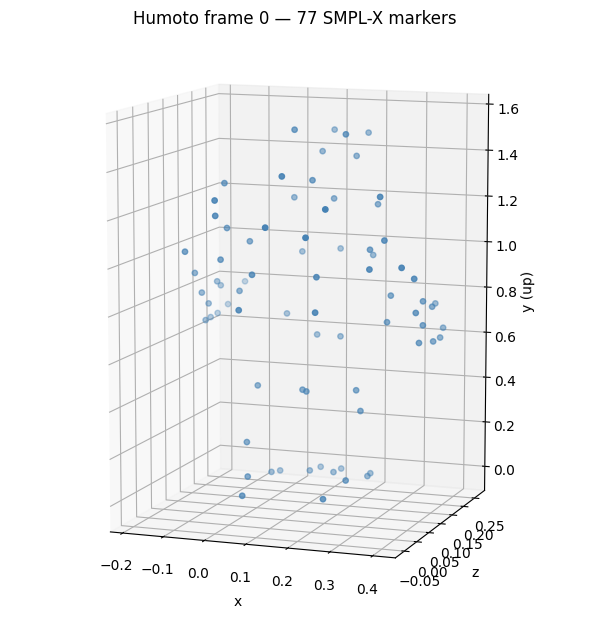

In [60]:
import numpy as np

seq_dir = f'/home/natcha/Downloads/projects/InterAct/data/humoto/sequences_canonical/{SEQ_NAME}'
motion  = np.load(f'{seq_dir}/motion.npy')

print(f"motion shape: {motion.shape}   (expect (293, 962))")
print(f"  markers block (0:231):     {motion[:, 0:231].shape}")
print(f"  marker vel    (231:462):   {motion[:, 231:462].shape}")
print(f"  foot contact  (462:476):   {motion[:, 462:476].shape}")
print(f"  object block  (476:962):   {motion[:, 476:962].shape}")

# Reshape markers and check they make a human silhouette
markers = motion[:, :231].reshape(-1, 77, 3)
print(f"\nmarkers frame 0:")
print(f"  shape: {markers.shape}")
print(f"  y range (height): [{markers[0,:,1].min():.3f}, {markers[0,:,1].max():.3f}]")
print(f"    expect roughly 0 (floor) to 1.6 (head) for a standing person")
print(f"  x range:          [{markers[0,:,0].min():.3f}, {markers[0,:,0].max():.3f}]")
print(f"  z range:          [{markers[0,:,2].min():.3f}, {markers[0,:,2].max():.3f}]")

# Plot frame 0 markers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
M = markers[0]
ax.scatter(M[:,0], M[:,2], M[:,1], c='steelblue', s=15)
ax.set_box_aspect((1, 1, 1.4))
ax.view_init(elev=10, azim=-70)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
ax.set_title(f"Humoto frame 0 — 77 SMPL-X markers")
plt.tight_layout(); plt.show()


Spatula world frame-0 centroid: [0.066 0.731 0.413]
Right wrist position:           [-0.144  0.827  0.141]
Distance from centroid to wrist: 0.357 m


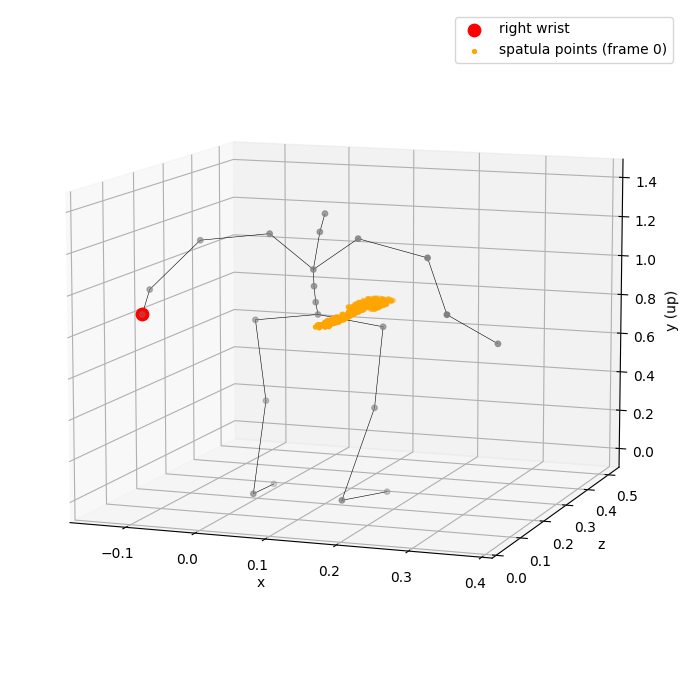

In [75]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Reload what we saved to make sure we're testing the on-disk version
loaded_pts = np.load(f'{out_obj_dir}/sample_points.npy')           # (340, 3) y-up local
loaded_obj = np.load(f'{out_seq_dir}/object.npz', allow_pickle=True)
ang0 = loaded_obj['angles'][0]      # (3,) frame-0 axis-angle
tr0  = loaded_obj['trans'][0]       # (3,) frame-0 translation

# Apply frame-0 transform: world_pts = R(ang0) @ local_pts + tr0
R0 = Rot.from_rotvec(ang0).as_matrix()
spatula_world = loaded_pts @ R0.T + tr0   # (340, 3)

# Right wrist in y-up from your earlier work
right_wrist = JM_yup[mx_model.bone_names.index('mixamorig:RightHand')]

print(f"Spatula world frame-0 centroid: {spatula_world.mean(0).round(3)}")
print(f"Right wrist position:           {right_wrist.round(3)}")
print(f"Distance from centroid to wrist: {np.linalg.norm(spatula_world.mean(0) - right_wrist):.3f} m")

# Plot: spatula points + right wrist + SMPL-X target skeleton for context
fig = plt.figure(figsize=(7, 8))
ax = fig.add_subplot(111, projection='3d')
# SMPL-X skeleton from your target_22
for k, p in enumerate(PARENTS):
    if p >= 0:
        ax.plot([target_22[p,0],target_22[k,0]],
                [target_22[p,2],target_22[k,2]],
                [target_22[p,1],target_22[k,1]], 'k-', lw=0.4)
ax.scatter(target_22[:,0], target_22[:,2], target_22[:,1], c='gray', s=15)
# Right wrist highlighted
ax.scatter([right_wrist[0]],[right_wrist[2]],[right_wrist[1]], c='red', s=80, label='right wrist')
# Spatula sample points
ax.scatter(spatula_world[:,0], spatula_world[:,2], spatula_world[:,1],
           c='orange', s=8, label='spatula points (frame 0)')
ax.legend(); ax.view_init(elev=10, azim=-70)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
plt.tight_layout(); plt.show()


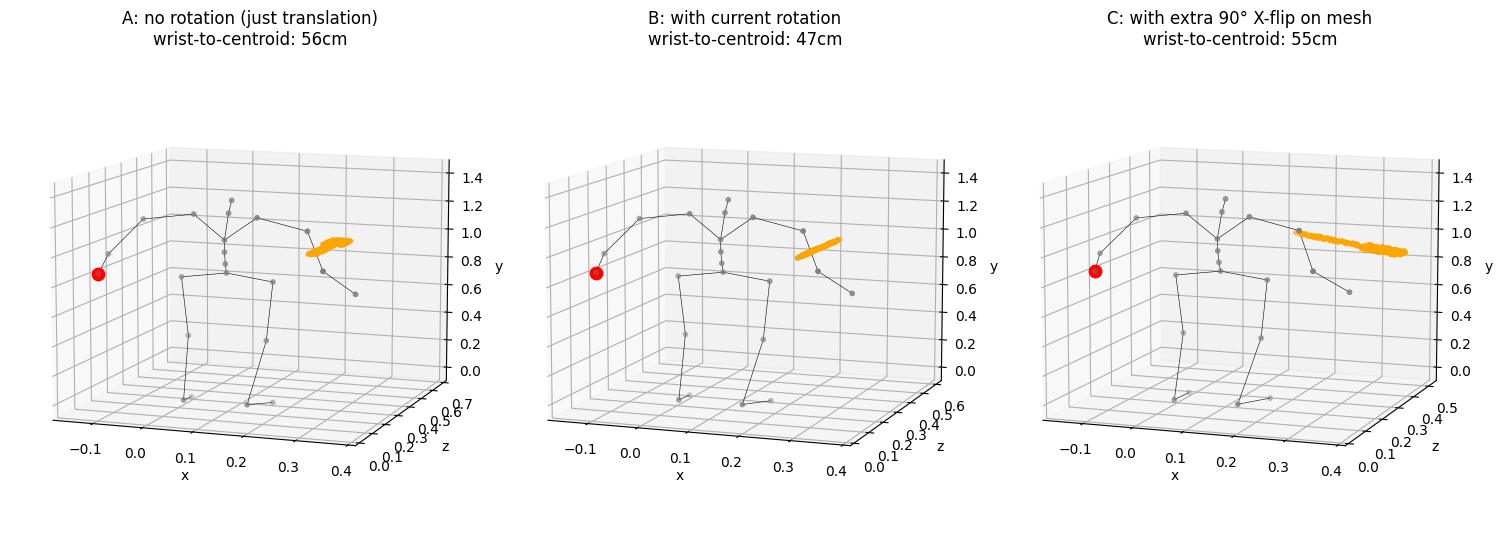

In [72]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Reload everything
loaded_pts = np.load(f'{out_obj_dir}/sample_points.npy')
loaded_obj = np.load(f'{out_seq_dir}/object.npz', allow_pickle=True)
ang0 = loaded_obj['angles'][73]
tr0  = loaded_obj['trans'][73]

# Three candidate world placements for frame 0
R_anim   = Rot.from_rotvec(ang0).as_matrix()
candidates = {
    'A: no rotation (just translation)':           loaded_pts + tr0,
    'B: with current rotation':                    loaded_pts @ R_anim.T + tr0,
    'C: with extra 90° X-flip on mesh':            (loaded_pts @ Rot.from_euler('x', 90, degrees=True).as_matrix().T) @ R_anim.T + tr0,
}

right_wrist = JM_yup[mx_model.bone_names.index('mixamorig:RightHand')]

fig = plt.figure(figsize=(15, 6))
for i, (label, pts) in enumerate(candidates.items()):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    # SMPL-X target skeleton
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([target_22[p,0],target_22[k,0]],
                    [target_22[p,2],target_22[k,2]],
                    [target_22[p,1],target_22[k,1]], 'k-', lw=0.4)
    ax.scatter(target_22[:,0], target_22[:,2], target_22[:,1], c='gray', s=10)
    ax.scatter([right_wrist[0]],[right_wrist[2]],[right_wrist[1]], c='red', s=80, label='r wrist')
    ax.scatter(pts[:,0], pts[:,2], pts[:,1], c='orange', s=6, label='spatula')
    d = np.linalg.norm(pts.mean(0) - right_wrist)
    ax.set_title(f"{label}\nwrist-to-centroid: {d*100:.0f}cm")
    ax.view_init(elev=10, azim=-70)
    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
plt.tight_layout(); plt.show()


In [73]:
from scipy.spatial.transform import Rotation as Rot
import trimesh, numpy as np

# 90° X-axis rotation: undoes the GLB y-up rest-pose offset
R_xflip = Rot.from_euler('x', 90, degrees=True).as_matrix()    # (3, 3)

# Apply to mesh vertices
spatula_oriented = trimesh.Trimesh(
    vertices=spatula_mesh.vertices @ R_xflip.T,
    faces   =spatula_mesh.faces,
)
print(f"Re-oriented bbox size: {(spatula_oriented.bounds[1] - spatula_oriented.bounds[0]).round(3)} m")

# Re-sample 340 points from the re-oriented mesh
np.random.seed(0)
points, _ = trimesh.sample.sample_surface(spatula_oriented, 340)

# Overwrite both files
np.save(f'{out_obj_dir}/sample_points.npy', points.astype(np.float32))
spatula_oriented.export(f'{out_obj_dir}/{OBJ_NAME}.obj')
print(f"Re-saved sample_points.npy {points.shape} and {OBJ_NAME}.obj")


Re-oriented bbox size: [0.044 0.253 0.008] m
Re-saved sample_points.npy (340, 3) and spatula.obj


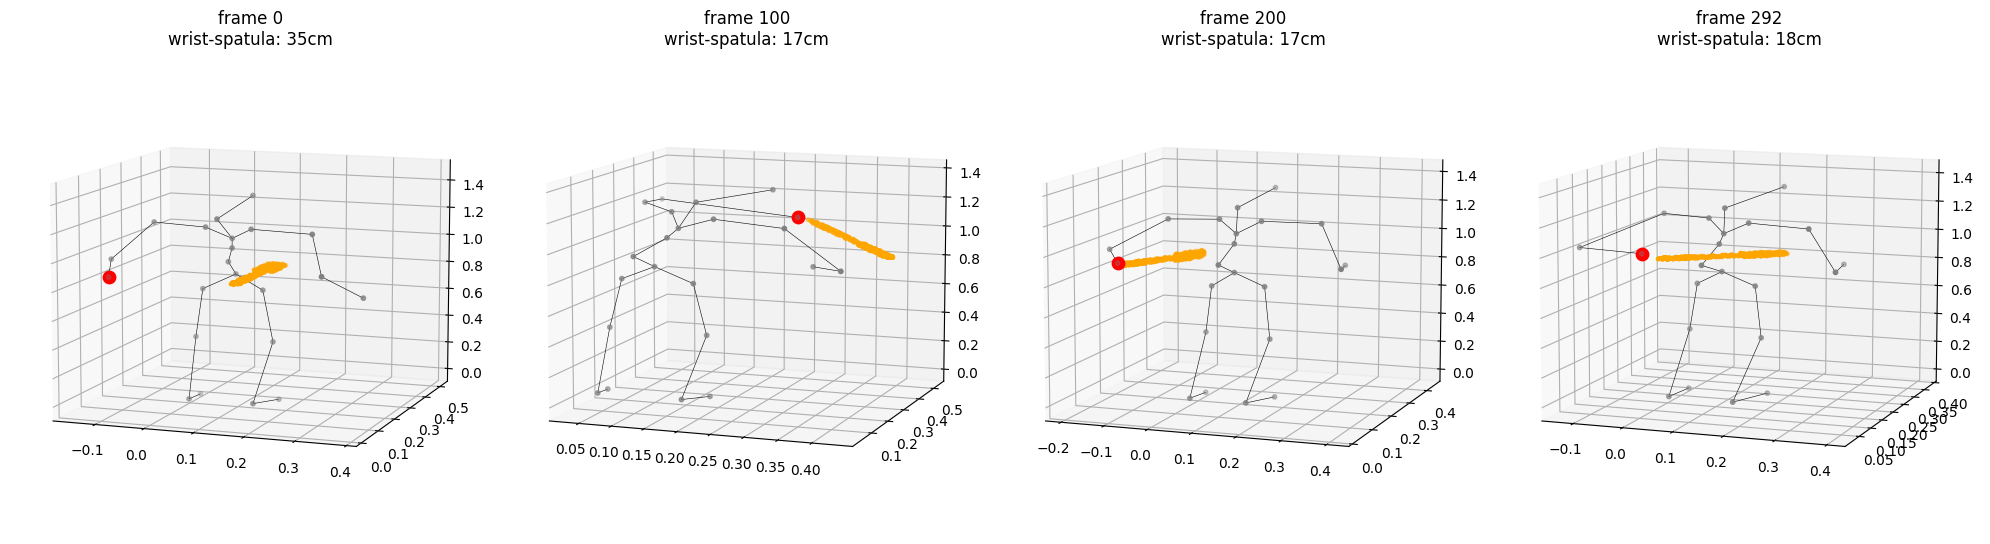

In [74]:
import matplotlib.pyplot as plt

loaded_pts = np.load(f'{out_obj_dir}/sample_points.npy')    # the X-flipped points
loaded_obj = np.load(f'{out_seq_dir}/object.npz', allow_pickle=True)
all_ang    = loaded_obj['angles']        # (T, 3)
all_tr     = loaded_obj['trans']         # (T, 3)

frames_to_show = [0, 100, 200, 292]      # span the sequence

fig = plt.figure(figsize=(20, 6))
for i, t in enumerate(frames_to_show):
    R_t  = Rot.from_rotvec(all_ang[t]).as_matrix()
    pts  = loaded_pts @ R_t.T + all_tr[t]

    # also compute the SMPL-X right wrist for this frame from fitted pose
    with torch.no_grad():
        out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
                body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
                transl       =torch.from_numpy(fitted_tr[t:t+1]),
                betas        =betas_fit)
        J = out.joints[0, :22].numpy()
    rwrist = J[21]

    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    for k, p in enumerate(PARENTS):
        if p >= 0:
            ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]], 'k-', lw=0.4)
    ax.scatter(J[:,0], J[:,2], J[:,1], c='gray', s=10)
    ax.scatter([rwrist[0]],[rwrist[2]],[rwrist[1]], c='red', s=80)
    ax.scatter(pts[:,0], pts[:,2], pts[:,1], c='orange', s=6)

    d = np.linalg.norm(pts.mean(0) - rwrist)
    ax.set_title(f"frame {t}\nwrist-spatula: {d*100:.0f}cm")
    ax.view_init(elev=10, azim=-70)
plt.tight_layout(); plt.show()


motion shape: (293, 962)    (expect (293, 962))
frame-0 marker y range: [0.003, 1.530]   (expect ~0 to ~1.6)


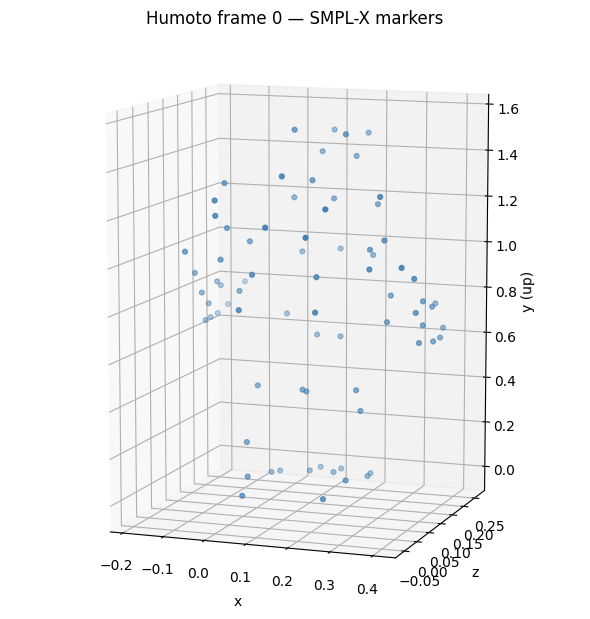

In [76]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

seq_dir = f'/home/natcha/Downloads/projects/InterAct/data/humoto/sequences_canonical/{SEQ_NAME}'
motion  = np.load(f'{seq_dir}/motion.npy')
print(f"motion shape: {motion.shape}    (expect (293, 962))")

markers = motion[:, :231].reshape(-1, 77, 3)
print(f"frame-0 marker y range: [{markers[0,:,1].min():.3f}, {markers[0,:,1].max():.3f}]   "
      f"(expect ~0 to ~1.6)")

# Plot frame-0 markers
M = markers[0]
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(M[:,0], M[:,2], M[:,1], c='steelblue', s=12)
ax.set_box_aspect((1, 1, 1.4)); ax.view_init(elev=10, azim=-70)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
ax.set_title("Humoto frame 0 — SMPL-X markers")
plt.tight_layout(); plt.show()


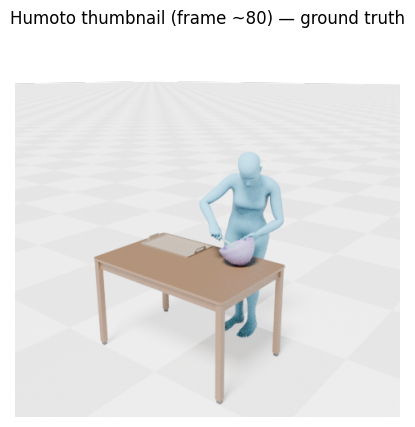

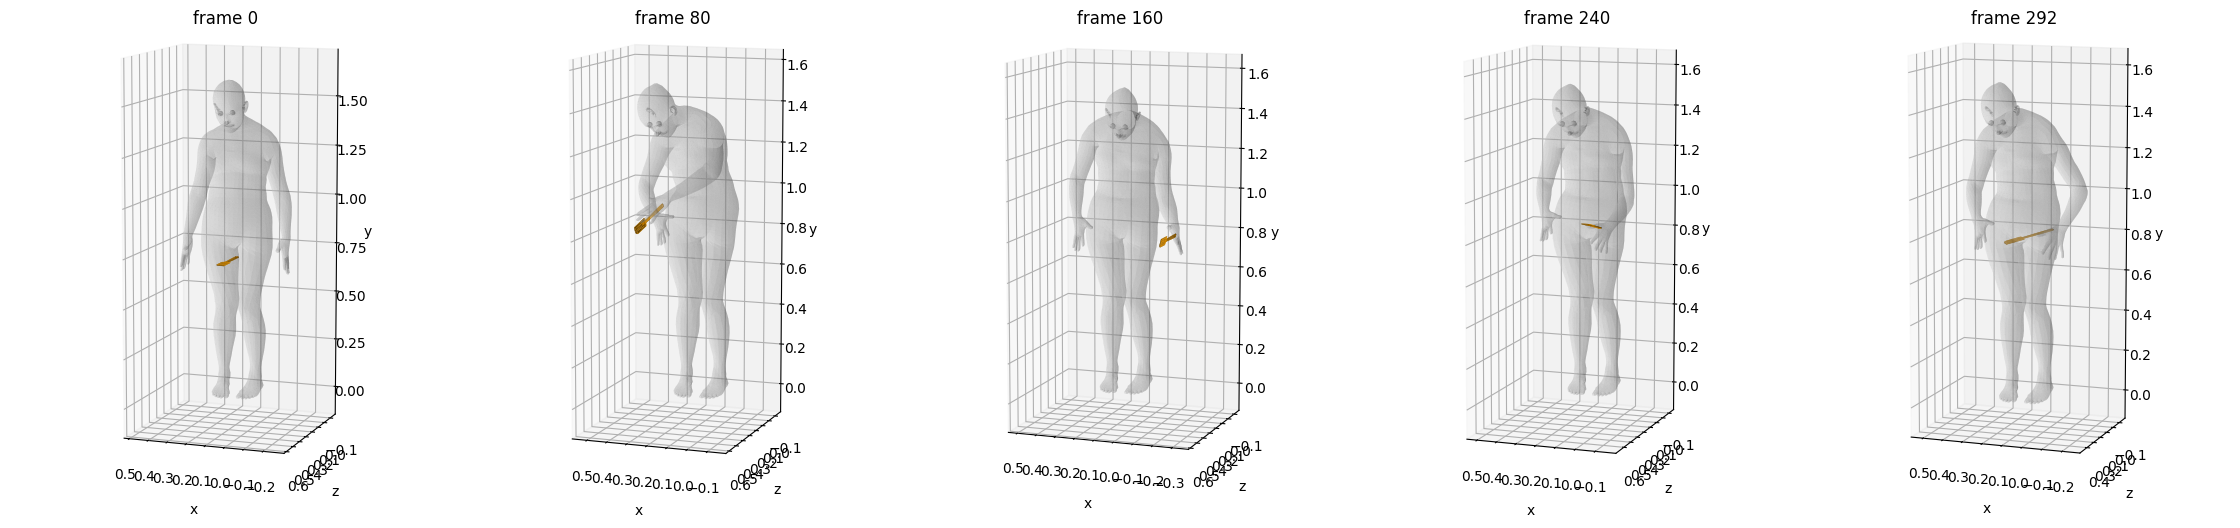

In [77]:
import trimesh
import matplotlib.image as mpimg

# Frames spread across the sequence (frame 80 matches the humoto thumbnail naming)
frames_to_show = [0, 80, 160, 240, 292]

# Load oriented spatula mesh
spatula_obj = trimesh.load(f'{out_obj_dir}/spatula.obj')

# ─── Render Humoto thumbnail for reference ────────────────────────────────
png_path = (f'/home/natcha/Downloads/projects/humoto_adobe/humoto/'
            f'{SEQ_NAME}/{SEQ_NAME}0080.png')
fig0 = plt.figure(figsize=(5, 5))
plt.imshow(mpimg.imread(png_path))
plt.title("Humoto thumbnail (frame ~80) — ground truth")
plt.axis('off')
plt.show()

# ─── Render SMPL-X + spatula for selected frames ──────────────────────────
fig = plt.figure(figsize=(4.5 * len(frames_to_show), 5.5))

for i, t in enumerate(frames_to_show):
    # SMPL-X mesh at frame t
    with torch.no_grad():
        out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
                body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
                transl       =torch.from_numpy(fitted_tr[t:t+1]),
                betas        =betas_fit)
    V_smplx = out.vertices[0].numpy()   # (10475, 3) — y-up
    F_smplx = m.faces                   # (20908, 3) int

    # Spatula mesh at frame t
    R_t = Rot.from_rotvec(loaded_obj['angles'][t]).as_matrix()
    V_sp = spatula_obj.vertices @ R_t.T + loaded_obj['trans'][t]
    F_sp = spatula_obj.faces

    ax = fig.add_subplot(1, len(frames_to_show), i+1, projection='3d')
    # SMPL-X body: translucent
    ax.plot_trisurf(V_smplx[:,0], V_smplx[:,2], V_smplx[:,1],
                    triangles=F_smplx, color='lightgray', alpha=0.25,
                    linewidth=0, edgecolor='none')
    # Spatula: opaque
    ax.plot_trisurf(V_sp[:,0], V_sp[:,2], V_sp[:,1],
                    triangles=F_sp, color='orange', alpha=0.95,
                    linewidth=0, edgecolor='none')

    # Use combined bounds so the body and spatula both fit comfortably
    pts = np.vstack([V_smplx, V_sp])
    lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect(((hi-lo)[0], (hi-lo)[2], (hi-lo)[1]))
    ax.view_init(elev=10, azim=110)        # view character from front
    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
    ax.set_title(f"frame {t}")

plt.tight_layout()
plt.show()


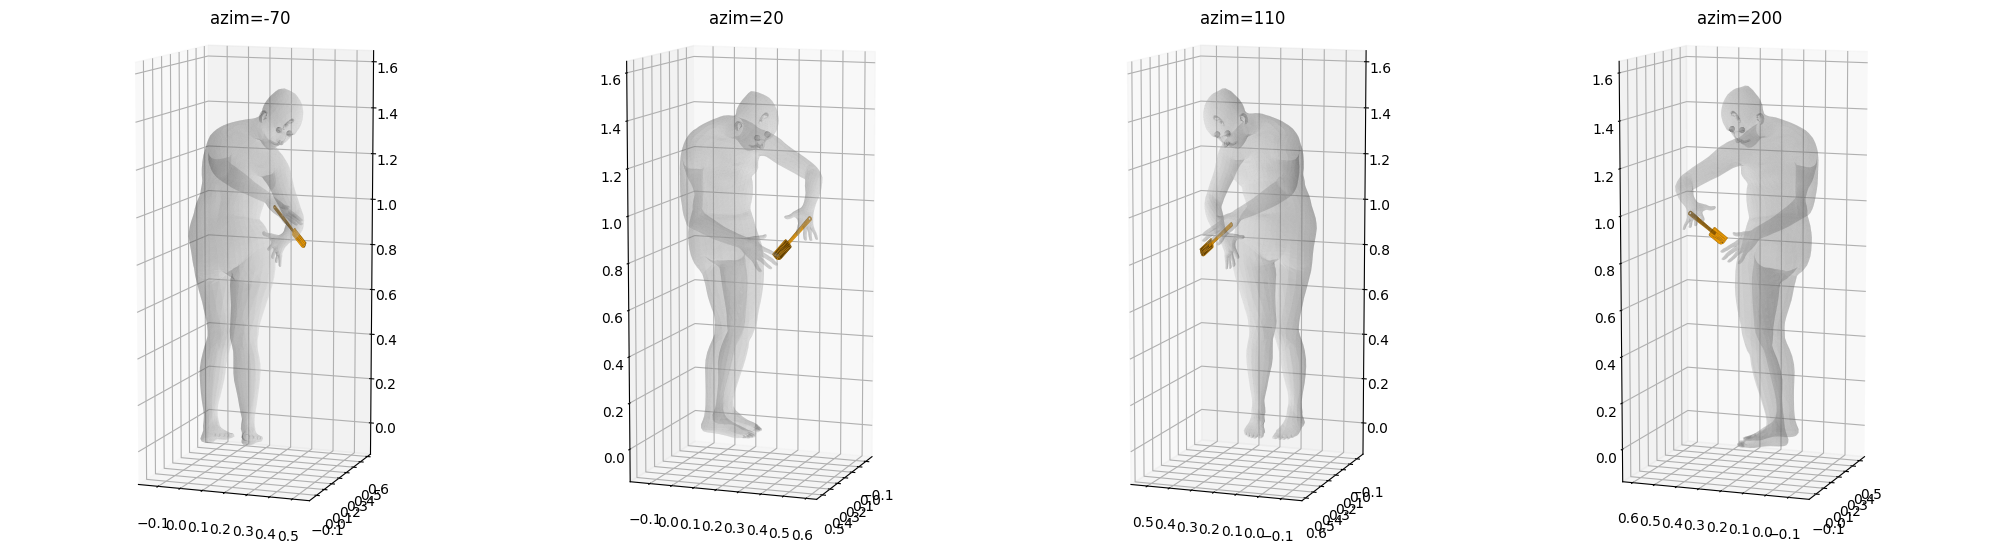

In [78]:
import trimesh
from scipy.spatial.transform import Rotation as Rot

t = 80
spatula_obj = trimesh.load(f'{out_obj_dir}/spatula.obj')

# Generate the meshes once
with torch.no_grad():
    out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
            body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
            transl       =torch.from_numpy(fitted_tr[t:t+1]),
            betas        =betas_fit)
V_smplx = out.vertices[0].numpy(); F_smplx = m.faces
R_t  = Rot.from_rotvec(loaded_obj['angles'][t]).as_matrix()
V_sp = spatula_obj.vertices @ R_t.T + loaded_obj['trans'][t]
F_sp = spatula_obj.faces

# Try 4 azim angles (90° apart). One should show the character's front.
azim_options = [-70, 20, 110, 200]
fig = plt.figure(figsize=(20, 5.5))
for i, az in enumerate(azim_options):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    ax.plot_trisurf(V_smplx[:,0], V_smplx[:,2], V_smplx[:,1],
                    triangles=F_smplx, color='lightgray', alpha=0.25, linewidth=0)
    ax.plot_trisurf(V_sp[:,0], V_sp[:,2], V_sp[:,1],
                    triangles=F_sp, color='orange', alpha=0.95, linewidth=0)
    pts = np.vstack([V_smplx, V_sp])
    lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect(((hi-lo)[0], (hi-lo)[2], (hi-lo)[1]))
    ax.view_init(elev=10, azim=az)
    ax.set_title(f"azim={az}")
plt.tight_layout(); plt.show()


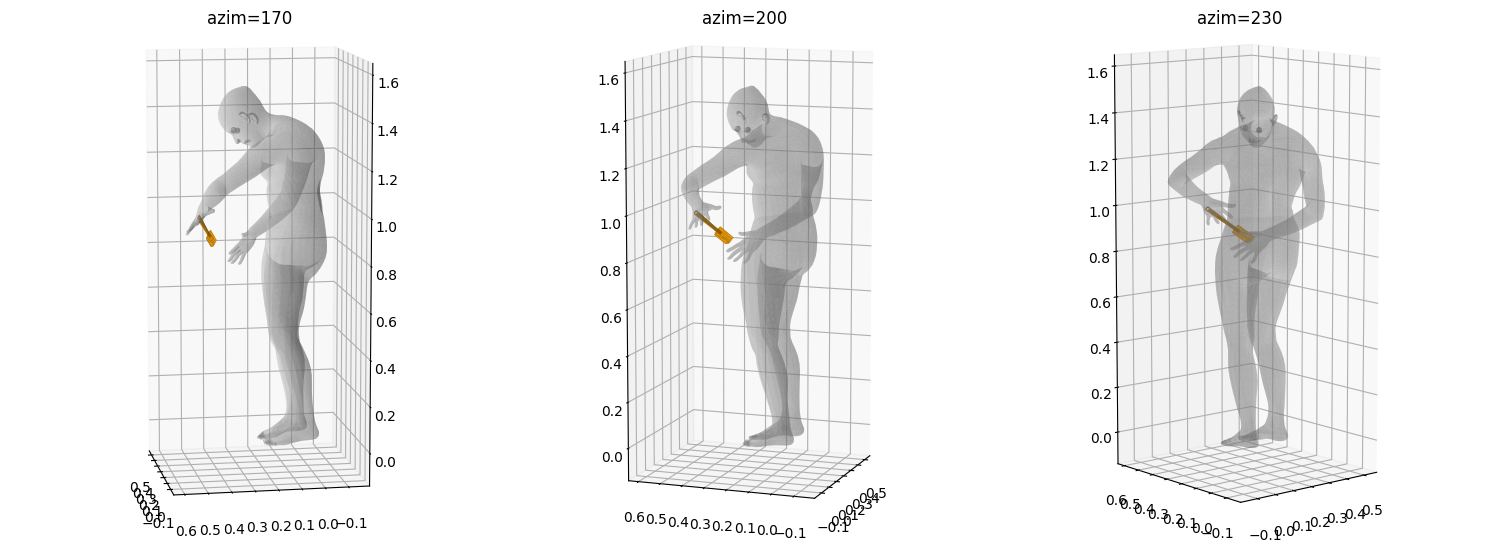

In [79]:
t = 80
# Get meshes (same as before)
with torch.no_grad():
    out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
            body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
            transl       =torch.from_numpy(fitted_tr[t:t+1]),
            betas        =betas_fit)
V_smplx = out.vertices[0].numpy(); F_smplx = m.faces
R_t  = Rot.from_rotvec(loaded_obj['angles'][t]).as_matrix()
V_sp = spatula_obj.vertices @ R_t.T + loaded_obj['trans'][t]
F_sp = spatula_obj.faces

# Three views: the good one (200) and its two neighbors to detect if the
# "legs and body opposite" thing is a real fit issue or a camera artifact
fig = plt.figure(figsize=(15, 6))
for i, az in enumerate([170, 200, 230]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_trisurf(V_smplx[:,0], V_smplx[:,2], V_smplx[:,1],
                    triangles=F_smplx, color='lightgray', alpha=0.35, linewidth=0)
    ax.plot_trisurf(V_sp[:,0], V_sp[:,2], V_sp[:,1],
                    triangles=F_sp, color='orange', alpha=0.95, linewidth=0)
    pts = np.vstack([V_smplx, V_sp])
    lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect(((hi-lo)[0], (hi-lo)[2], (hi-lo)[1]))
    ax.view_init(elev=10, azim=az)
    ax.set_title(f"azim={az}")
plt.tight_layout(); plt.show()


In [80]:
def axis_angle_to_deg(aa):
    angle = np.linalg.norm(aa)
    return angle * 180 / np.pi

t = 80
bp = fitted_bp[t]
joints_to_check = [
    (3,  'spine1', 6),    # body_pose[6:9]
    (6,  'spine2', 15),   # body_pose[15:18]
    (9,  'spine3', 24),   # body_pose[24:27]
    (12, 'neck',   33),
    (15, 'head',   42),
]
print(f"Frame {t} spine/neck/head rotations:")
print(f"  {'joint':10s}  {'axis-angle':30s}  {'magnitude':>10s}  {'Y-comp (yaw)':>14s}")
for j_idx, name, slice_start in joints_to_check:
    aa = bp[slice_start:slice_start+3]
    mag = axis_angle_to_deg(aa)
    print(f"  {name:10s}  ({aa[0]:+.3f}, {aa[1]:+.3f}, {aa[2]:+.3f})  "
          f"{mag:>8.1f}°  {aa[1]*180/np.pi:>12.1f}°")

# Also check global_orient
go = fitted_go[t]
print(f"\nglobal_orient: ({go[0]:+.3f}, {go[1]:+.3f}, {go[2]:+.3f})  "
      f"magnitude={axis_angle_to_deg(go):.1f}°  yaw(Y-comp)={go[1]*180/np.pi:.1f}°")


Frame 80 spine/neck/head rotations:
  joint       axis-angle                       magnitude    Y-comp (yaw)
  spine1      (+0.649, -0.023, -0.297)      40.9°          -1.3°
  spine2      (-0.416, +0.164, -0.015)      25.6°           9.4°
  spine3      (+0.380, +0.290, +0.090)      27.9°          16.6°
  neck        (+0.740, -0.138, +0.059)      43.3°          -7.9°
  head        (+0.000, +0.000, +0.000)       0.0°           0.0°

global_orient: (-0.292, +0.136, +0.073)  magnitude=18.9°  yaw(Y-comp)=7.8°


In [ ]:
import os, pickle, shutil
import numpy as np, torch, trimesh
from scipy.spatial.transform import Rotation as Rot
import torch.optim as optim

# Module-level constants (already defined above in your notebook, but here for clarity)
Z_TO_Y_MAT  = np.array([[1, 0, 0],
                        [0, 0, 1],
                        [0,-1, 0]], dtype=np.float32)
R_XFLIP_MAT = Rot.from_euler('x', 90, degrees=True).as_matrix()


def process_humoto_sequence(
    pkl_path,
    glb_path,
    seq_name,
    primary_object,
    output_root,
    smplx_model,                # the global `m` from your setup
    mx_model,                   # the humoto HumanModelDifferentiable
    body_corr,                  # BODY_CORR from your setup
    seed=0,
    verbose=True,
):
    """
    End-to-end Humoto → InterAct conversion for ONE sequence.

    Writes:
      {output_root}/sequences_canonical/{seq_name}/human.npz
      {output_root}/sequences_canonical/{seq_name}/object.npz
      {output_root}/objects/{primary_object}/sample_points.npy
      {output_root}/objects/{primary_object}/{primary_object}.obj

    Returns: dict {seq_dir, obj_dir, betas, mean_err_cm, max_err_cm, T}
    """
    # Set all RNGs at the start for reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    Z_TO_Y_R = Rot.from_matrix(Z_TO_Y_MAT.astype(np.float64))

    # ─── 1. Load pickle, compute Mixamo joint targets in y-up ──────────────
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    arm, objs = data['armature'], data['objects']
    T = len(arm)
    if primary_object not in objs:
        raise ValueError(f"'{primary_object}' not in pickle objects: {list(objs.keys())}")

    def _frame_to_pose_params(frame_dict):
        pp = {}
        for bone, entry in frame_dict.items():
            e = np.asarray(entry, dtype=np.float32)
            w, x, y, z = e[:4]; lx, ly, lz = e[4:]
            R = Rot.from_quat([x, y, z, w]).as_matrix()
            M = np.eye(4, dtype=np.float32)
            M[:3,:3] = R; M[:3,3] = [lx, ly, lz]
            pp[bone] = torch.from_numpy(M).unsqueeze(0)
        return pp

    all_targets = np.zeros((T, 22, 3), dtype=np.float32)
    for t in range(T):
        with torch.no_grad():
            _, jp_t = mx_model(_frame_to_pose_params(arm[t]))
        JM_zup = np.stack([jp_t[b].numpy()[0] for b in mx_model.bone_names])
        JM_yup = JM_zup @ Z_TO_Y_MAT.T
        for smplx_idx, _, mx_name in body_corr:
            mx_idx = mx_model.bone_names.index(mx_name)
            all_targets[t, smplx_idx] = JM_yup[mx_idx]

    if verbose:
        print(f"[1/4] Loaded pickle: T={T}, objects={list(objs.keys())}")

    # ─── 2. Joint-position β-fit on frame 0 (β + pose + trans jointly) ─────
    target_0 = torch.from_numpy(all_targets[0])
    pelvis_neutral = smplx_model(betas=torch.zeros(1, 16)).joints[0, 0].detach()
    trans_init = (target_0[0] - pelvis_neutral)

    betas         = torch.zeros(1, 16, requires_grad=True)
    global_orient = torch.zeros(1, 3,  requires_grad=True)
    body_pose     = torch.zeros(1, 63, requires_grad=True)
    trans         = trans_init.unsqueeze(0).clone().requires_grad_(True)
    opt = optim.Adam([betas, global_orient, body_pose, trans], lr=0.05)

    for step in range(600):
        out  = smplx_model(global_orient=global_orient, body_pose=body_pose,
                           transl=trans, betas=betas)
        pred = out.joints[0, :22]
        loss = (((pred - target_0)**2).mean()
                + 0.001  * (betas**2).mean()
                + 0.0005 * (body_pose**2).mean())
        opt.zero_grad(); loss.backward(); opt.step()

    betas_fit = betas.detach().clone()
    fitted_go = np.zeros((T, 3),  dtype=np.float32)
    fitted_bp = np.zeros((T, 63), dtype=np.float32)
    fitted_tr = np.zeros((T, 3),  dtype=np.float32)
    fitted_go[0] = global_orient.detach()[0].numpy()
    fitted_bp[0] = body_pose.detach()[0].numpy()
    fitted_tr[0] = trans.detach()[0].numpy()

    # ─── 3. Per-frame pose fit (β frozen, warm-started from t-1) ───────────
    errors = np.zeros(T, dtype=np.float32)
    for t in range(1, T):
        go_var = torch.from_numpy(fitted_go[t-1:t]).clone().requires_grad_(True)
        bp_var = torch.from_numpy(fitted_bp[t-1:t]).clone().requires_grad_(True)
        tr_var = torch.from_numpy(fitted_tr[t-1:t]).clone().requires_grad_(True)
        target_t = torch.from_numpy(all_targets[t])
        bp_prev  = torch.from_numpy(fitted_bp[t-1:t])

        opt = optim.Adam([go_var, bp_var, tr_var], lr=0.03)
        for step in range(80):
            out  = smplx_model(global_orient=go_var, body_pose=bp_var,
                               transl=tr_var, betas=betas_fit)
            pred = out.joints[0, :22]
            loss = (((pred - target_t)**2).mean()
                    + 0.0005 * (bp_var**2).mean()
                    + 0.01   * ((bp_var - bp_prev)**2).mean())
            opt.zero_grad(); loss.backward(); opt.step()

        fitted_go[t] = go_var.detach()[0].numpy()
        fitted_bp[t] = bp_var.detach()[0].numpy()
        fitted_tr[t] = tr_var.detach()[0].numpy()
        with torch.no_grad():
            errors[t] = (pred - target_t).norm(dim=1).mean().item()

    if verbose:
        print(f"[2/4] Fit: mean={errors.mean()*100:.2f}cm, max={errors.max()*100:.2f}cm, ||β||={betas_fit.norm():.2f}")

    # ─── 4. Save human.npz + object.npz ────────────────────────────────────
    out_seq_dir = os.path.join(output_root, 'sequences_canonical', seq_name)
    out_obj_dir = os.path.join(output_root, 'objects', primary_object)
    os.makedirs(out_seq_dir, exist_ok=True)
    os.makedirs(out_obj_dir, exist_ok=True)

    poses = np.concatenate([fitted_go, fitted_bp,
                            np.zeros((T, 90), dtype=np.float32)], axis=1)
    np.savez(os.path.join(out_seq_dir, 'human.npz'),
             poses=poses.astype(np.float32),
             betas=betas_fit[0].numpy().astype(np.float32),
             trans=fitted_tr.astype(np.float32),
             gender='neutral')

    obj_zup       = np.array(objs[primary_object], dtype=np.float32)
    obj_trans_yup = obj_zup[:, 4:] @ Z_TO_Y_MAT.T
    quat_xyzw     = obj_zup[:, [1, 2, 3, 0]]
    obj_rot_yup   = Z_TO_Y_R * Rot.from_quat(quat_xyzw)
    obj_angles    = obj_rot_yup.as_rotvec().astype(np.float32)
    np.savez(os.path.join(out_seq_dir, 'object.npz'),
             angles=obj_angles,
             trans=obj_trans_yup.astype(np.float32),
             name=primary_object)

    # ─── 5. Extract + orient mesh + sample 340 points ──────────────────────
    scene = trimesh.load(glb_path)
    obj_mesh = scene.geometry[primary_object]
    obj_oriented = trimesh.Trimesh(
        vertices=obj_mesh.vertices @ R_XFLIP_MAT.T,
        faces=obj_mesh.faces)
    np.random.seed(seed)   # re-seed JUST before sampling
    sample_pts, _ = trimesh.sample.sample_surface(obj_oriented, 340)
    np.save(os.path.join(out_obj_dir, 'sample_points.npy'), sample_pts.astype(np.float32))
    obj_oriented.export(os.path.join(out_obj_dir, f'{primary_object}.obj'))

    if verbose:
        print(f"[3/4] Saved canonical to {out_seq_dir}")
        print(f"[4/4] Saved object to   {out_obj_dir}")

    return {
        'seq_dir': out_seq_dir,
        'obj_dir': out_obj_dir,
        'betas': betas_fit[0].numpy(),
        'mean_err_cm': float(errors.mean() * 100),
        'max_err_cm':  float(errors.max()  * 100),
        'T': T,
    }


In [ ]:
SEQ_NAME    = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
PRIMARY_OBJ = 'spatula'
PKL_PATH    = f'/media/natcha/Natcha_T7/InterAct_workspace/humoto_upbone/{SEQ_NAME}/{SEQ_NAME}.pkl'
GLB_PATH    = f'/home/natcha/Downloads/projects/humoto_adobe/humoto/{SEQ_NAME}/{SEQ_NAME}.glb'
OUTPUT_ROOT = '/home/natcha/Downloads/projects/InterAct/data/humoto'
BACKUP_ROOT = '/tmp/humoto_run_a'

# ─── Run A — write to backup location ─────────────────────────────────────
result_a = process_humoto_sequence(
    pkl_path=PKL_PATH, glb_path=GLB_PATH,
    seq_name=SEQ_NAME, primary_object=PRIMARY_OBJ,
    output_root=BACKUP_ROOT,
    smplx_model=m, mx_model=mx_model, body_corr=BODY_CORR, seed=0,
)
print("Run A:", result_a)

# ─── Run B — write to the real data/ location ─────────────────────────────
# clear old contents first
shutil.rmtree(os.path.join(OUTPUT_ROOT, 'sequences_canonical', SEQ_NAME), ignore_errors=True)
shutil.rmtree(os.path.join(OUTPUT_ROOT, 'objects',          PRIMARY_OBJ), ignore_errors=True)

result_b = process_humoto_sequence(
    pkl_path=PKL_PATH, glb_path=GLB_PATH,
    seq_name=SEQ_NAME, primary_object=PRIMARY_OBJ,
    output_root=OUTPUT_ROOT,
    smplx_model=m, mx_model=mx_model, body_corr=BODY_CORR, seed=0,
)
print("Run B:", result_b)

# ─── Compare every file ────────────────────────────────────────────────────
def diff_npz(a_path, b_path):
    a = np.load(a_path, allow_pickle=True)
    b = np.load(b_path, allow_pickle=True)
    out = {}
    for k in a.files:
        va, vb = a[k], b[k]
        if va.dtype.kind in 'fiub':
            out[k] = float(np.abs(va.astype(float) - vb.astype(float)).max())
        else:
            out[k] = 'equal' if (va == vb).all() else 'DIFF'
    return out

def diff_npy(a_path, b_path):
    return float(np.abs(np.load(a_path) - np.load(b_path)).max())

print("\n=== Reproducibility check ===")
print("human.npz:", diff_npz(
    f'{BACKUP_ROOT}/sequences_canonical/{SEQ_NAME}/human.npz',
    f'{OUTPUT_ROOT}/sequences_canonical/{SEQ_NAME}/human.npz'))
print("object.npz:", diff_npz(
    f'{BACKUP_ROOT}/sequences_canonical/{SEQ_NAME}/object.npz',
    f'{OUTPUT_ROOT}/sequences_canonical/{SEQ_NAME}/object.npz'))
print("sample_points.npy max diff:", diff_npy(
    f'{BACKUP_ROOT}/objects/{PRIMARY_OBJ}/sample_points.npy',
    f'{OUTPUT_ROOT}/objects/{PRIMARY_OBJ}/sample_points.npy'))
